### **Organizando os gráficos da seção de resultados**

1. Análise dos tópicos e toxicidade
2. Análise de difusão
3. Análise temporal

In [1]:
import pandas as pd 

df_all = pd.read_parquet("data/not_27.parquet")
df_all.head()

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'date': '2024-04-14', 'folder': 'channel_155...",0.000659,0.000117,...,0.138744,0.360951,0.367026,0.038566,Others,0.000000,1.0,1,3.0,2024-04-14
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'date': '2024-01-06', 'folder': 'channel_146...",0.295000,0.001137,...,0.008414,0.123468,0.049762,0.029415,Religion,0.000000,1.0,1,79.0,2024-01-06
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'date': '2024-02-22', 'folder': 'channel_123...",0.001735,0.000102,...,0.003292,0.229804,0.062040,0.033386,Others,0.021935,1.0,4,0.0,2024-02-22
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'date': '2024-10-27', 'folder': 'channel_157...",0.002710,0.000104,...,0.001093,0.075294,0.017666,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'date': '2024-02-06', 'folder': 'channel_143...",0.001515,0.000100,...,0.002368,0.111507,0.019375,0.028207,Environment,0.000000,2.0,2,0.0,2024-02-06


In [2]:
df_all['macrotopic_pred'] = ['Crime, S. and J.' if topic == 'Crime, Security and Justice' else topic for topic in df_all['macrotopic_pred']]
df_all['macrotopic_pred'] = ['US Politics' if topic == 'American Politics' else topic for topic in df_all['macrotopic_pred']]

df_all = df_all[df_all['perspective_toxicity'].notna()]
print(f"Número de linhas após filtrar valores nulos em 'perspective_toxicity': {len(df_all)}")

Número de linhas após filtrar valores nulos em 'perspective_toxicity': 673586


In [3]:
tox_cols = [
    'perspective_toxicity',
    'perspective_severe_toxicity',
    'perspective_insult',
    'perspective_obscene',
    'perspective_threat',
    'perspective_identity_attack'
]

In [4]:
politics = ['US Politics', 'War', 'Foreign Policy', 'Crime, S. and J.']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

palette_map = {}

for topic in non_politics:
    palette_map[topic] = "#577a8b"  

for topic in politics:
    palette_map[topic] = "#f4a04c"   
interest = [
    'War',
    'US Politics',
    'Foreign Policy',
    'Crime, S. and J.',
    'Health',
    'Religion',
    'Hobbies'
    ,"Technology"
    ,"Environment"
    ,"Entertainment"
]
"""
macro_colors = {
    "US Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, S. and J.":     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
    , "Technology": "#890082"
    , "Environment": "#008000"
    , "Entertainment": "#FFD700"
}
"""
macro_colors = {
    "US Politics":             "#5FD6DE",  # era #6AF5FF
    "Foreign Policy":               "#4CBD71",  # era #76FF7F
    "Crime, S. and J.":   "#F07AA8",  # era #FF66CC
    "Health":                       "#6A3A3A",  # era #522222
    "Hobbies":                      "#C43A3A",  # era #DA0000
    "Religion":                     "#8E5FA6",  # era #962EAA
    "War":                          "#6B6F78"   # era #5C5C61
    , "Technology": "#7A0078"      # versão mais suave do #890082
    , "Environment": "#2F8F4E"     # versão mais suave do #008000
    , "Entertainment": "#E6C24A"   # versão mais suave do #FFD700
}

df = df_all[df_all["macrotopic_pred"].isin(interest)]
len(df)

427959

In [5]:
"""
import numpy as np
import matplotlib.pyplot as plt

macro_colors = {
    "American Politics":             "#5FD6DE",  # era #6AF5FF
    "Foreign Policy":               "#4CBD71",  # era #76FF7F
    "Crime, Security and Justice":   "#F07AA8",  # era #FF66CC
    "Health":                       "#6A3A3A",  # era #522222
    "Hobbies":                      "#C43A3A",  # era #DA0000
    "Religion":                     "#8E5FA6",  # era #962EAA
    "War":                          "#6B6F78"   # era #5C5C61
    #, "Technology": "#7A0078"      # versão mais suave do #890082
    #, "Environment": "#2F8F4E"     # versão mais suave do #008000
    #, "Entertainment": "#E6C24A"   # versão mais suave do #FFD700
}

politics = ['American Politics', 'War', 'Foreign Policy', 'Crime, Security and Justice']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

toxicity_mean = df_all.groupby('macrotopic_pred')['perspective_toxicity'].mean()

# ordena do mais tóxico → menos tóxico
politics_sorted = sorted(politics, key=lambda g: toxicity_mean.get(g, 0), reverse=True)
non_politics_sorted = sorted(non_politics, key=lambda g: toxicity_mean.get(g, 0), reverse=True)

# colormaps bons e bem separados
cmap_pol = plt.get_cmap("Oranges")
cmap_non = plt.get_cmap("Blues")

# mais tóxico → cor mais forte
norm_pol = np.linspace(0.85, 0.35, len(politics_sorted))
norm_non = np.linspace(0.85, 0.35, len(non_politics_sorted))

macro_colors = {}

for g, n in zip(politics_sorted, norm_pol):
    macro_colors[g] = cmap_pol(n)

for g, n in zip(non_politics_sorted, norm_non):
    macro_colors[g] = cmap_non(n)
"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nmacro_colors = {\n    "American Politics":             "#5FD6DE",  # era #6AF5FF\n    "Foreign Policy":               "#4CBD71",  # era #76FF7F\n    "Crime, Security and Justice":   "#F07AA8",  # era #FF66CC\n    "Health":                       "#6A3A3A",  # era #522222\n    "Hobbies":                      "#C43A3A",  # era #DA0000\n    "Religion":                     "#8E5FA6",  # era #962EAA\n    "War":                          "#6B6F78"   # era #5C5C61\n    #, "Technology": "#7A0078"      # versão mais suave do #890082\n    #, "Environment": "#2F8F4E"     # versão mais suave do #008000\n    #, "Entertainment": "#E6C24A"   # versão mais suave do #FFD700\n}\n\npolitics = [\'American Politics\', \'War\', \'Foreign Policy\', \'Crime, Security and Justice\']\nnon_politics = [\'Health\', \'Hobbies\', \'Religion\', \'Entertainment\', \'Technology\', \'Environment\']\n\ntoxicity_mean = df_all.groupby(\'macrotopic_pred\')[\'perspectiv

In [6]:
df_exploded = df.explode('occurrences').reset_index(drop=True)
df_normalized = pd.json_normalize(df_exploded['occurrences'])
df_complete = pd.concat([
    df_exploded.drop(columns=['occurrences']), 
    df_normalized
], axis=1)
display(df_complete.head())

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,toxicity,severe_toxicity,obscene,...,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance,date,folder,id
0,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,0.29500,0.001137,0.003694,...,0.029415,Religion,0.000,1.0,1,79.0,2024-01-06,2024-01-06,channel_1466271872,60799.0
1,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_1571505334,449843.0
2,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-28,channel_1366456452,205296.0
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_2091154967,123625.0
4,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,2024-10-27,channel_1548295614,462353.0


___
## **RQ1 Analisando características de cada tópico**

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',  
    'font.size': 22,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.titlesize': 22,
    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",
    'font.weight': 700, 
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png' 

#### NOV

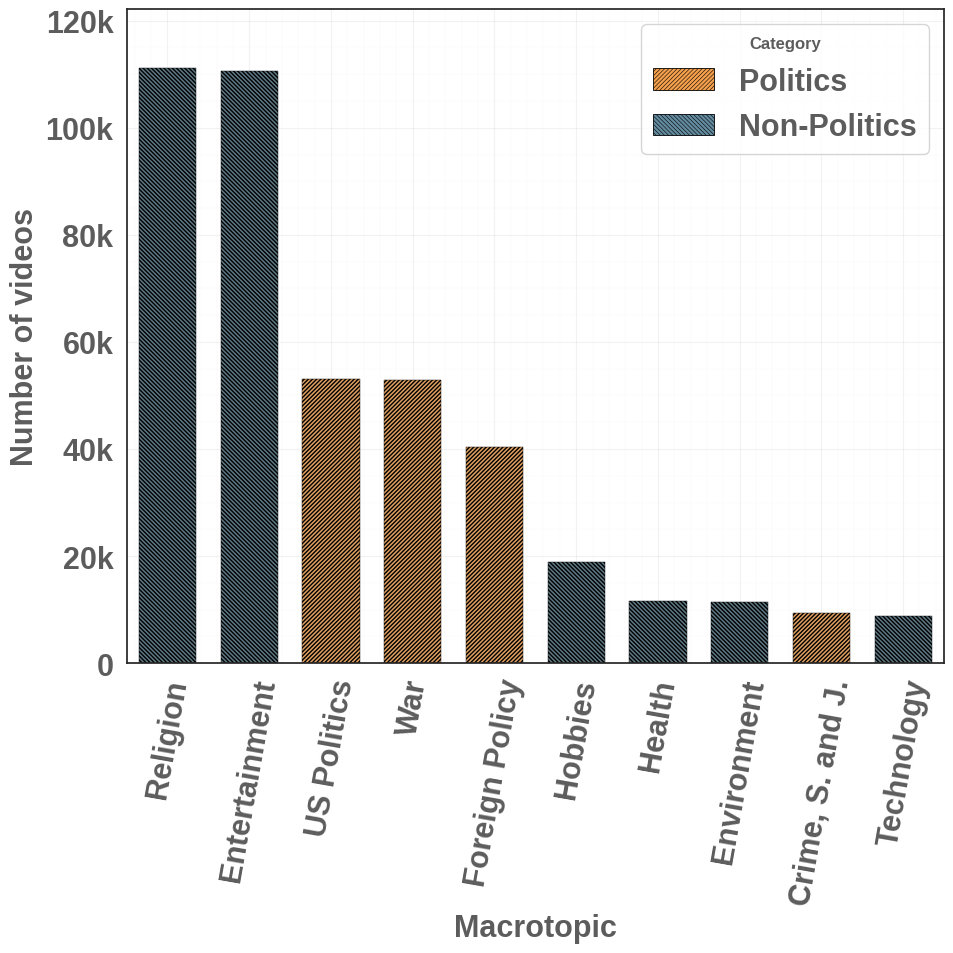

In [8]:
from matplotlib.patches import Patch
import matplotlib as mpl

topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(10, 10))

ax = sns.barplot(
    x='macrotopic_pred',     # ← volta para x
    y='count',               # ← volta para y
    hue='macrotopic_pred',
    data=topic_count,
    palette=palette_map,
    width=0.7,
    legend=False
)

# aplnotebooksica hatching (padrões) para P&B
for patch, topic in zip(ax.patches, topic_count['macrotopic_pred']):
    if topic in politics:
        patch.set_hatch('////////')      # 8 barras
    else:
        patch.set_hatch('\\\\\\\\\\\\\\\\')  # 8 barras invertidas

    patch.set_edgecolor('black')
    patch.set_linewidth(0.3)

mpl.rcParams['hatch.linewidth'] = 0.4

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)

plt.xlabel('Macrotopic')
plt.ylabel('Number of videos')

plt.xticks(rotation=80)
plt.yticks()

# agora o limite é no eixo Y
plt.ylim(0, topic_count['count'].max() * 1.1)

legend_elements = [
    Patch(facecolor='#f4a04c',
          edgecolor='black',
          hatch='////////',
          label='Politics',
          linewidth=0.6),

    Patch(facecolor='#638b9f',
          edgecolor='black',
          hatch='\\\\\\\\\\\\\\\\',
          label='Non-Politics',
          linewidth=0.6)
]

plt.legend(
    handles=legend_elements,
    title='Category',
    loc='upper right',
    frameon=True
)

plt.legend(handles=legend_elements, title='Category', loc='upper right')

from matplotlib.ticker import FuncFormatter

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}')
)

plt.tight_layout()
#plt.savefig("gráficos/num_videos_per_macrotopic_vertical.svg", format='svg')
plt.show()

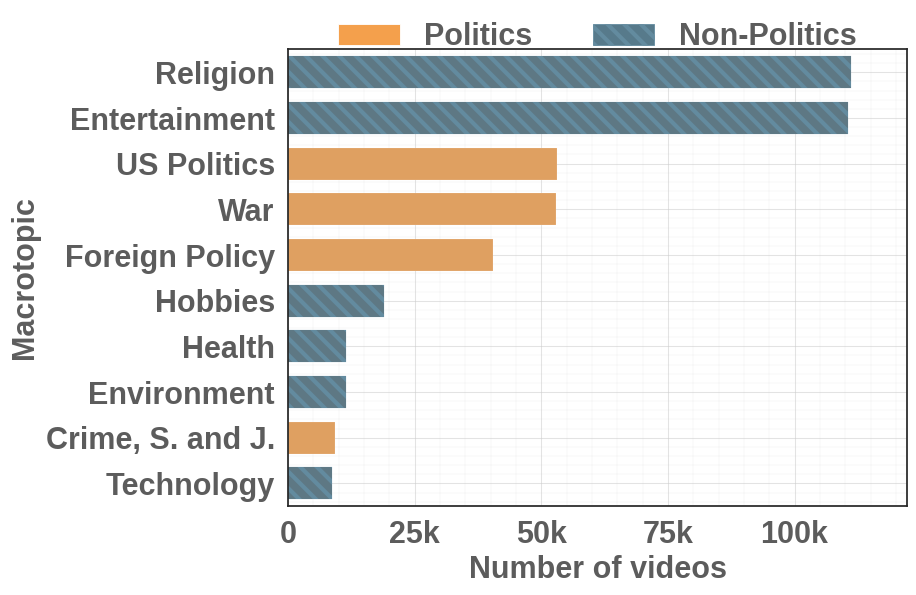

In [10]:
from matplotlib.patches import Patch

topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    y='macrotopic_pred',     
    x='count',             
    hue='macrotopic_pred',
    data=topic_count,
    palette=palette_map,
    width=0.7,
    legend=False
)

for patch, topic in zip(ax.patches, topic_count['macrotopic_pred']):
    if topic in politics:
        #patch.set_hatch('//')      # 8 barras
        #patch.set_edgecolor("#f0b77e")
        i=0
    else:
        patch.set_hatch('\\\\')  # 8 barras invertidas
        patch.set_edgecolor('#638b9f')
    #patch.set_edgecolor("#353535")
    patch.set_linewidth(0.1)

mpl.rcParams['hatch.linewidth'] = 3

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

plt.xlabel('Number of videos')
plt.ylabel('Macrotopic')

plt.yticks()
plt.xticks()

plt.xlim(0, topic_count['count'].max() * 1.1)

legend_elements = [
    Patch(facecolor=palette_map['War'],
          #edgecolor='#f0b77e',
          #hatch='//',
          label='Politics',
          linewidth=0.6),

    Patch(facecolor=palette_map['Religion'],
          edgecolor='#638b9f',
          hatch='\\\\',
          label='Non-Politics',
          linewidth=0.6)
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

from matplotlib.ticker import FuncFormatter

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}')
)

plt.savefig(f"gráficos/num_videos_per_macrotopic_horizontal.{format}", format=format, bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib.patches import Patch

topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(10, 10))

ax = sns.barplot(
    x='macrotopic_pred',     
    y='count',             
    data=topic_count,
    palette=palette_map,
    width=0.7,
    legend=False
)

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of videos per Macrotopic')
plt.xlabel('Number of videos')
plt.ylabel('Macrotopic')

plt.yticks()
plt.xticks()

plt.xlim(0, topic_count['count'].max() * 1.1)

legend_elements = [
    Patch(facecolor='orange', label='Politics'),
    Patch(facecolor='blue',   label='Non-Politics'),
]

plt.legend(handles=legend_elements, title='Category', loc='upper right')

plt.tight_layout()
plt.savefig("gráficos/num_videos_per_macrotopic_horizontal.svg", format='svg')
plt.show()

/tmp/ipykernel_3478994/3573838107.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
Locator attempting to generate 610891 ticks ([0.0, ..., 122178.0]), which exceeds Locator.MAXTICKS (1000).


KeyboardInterrupt: 

Locator attempting to generate 610891 ticks ([0.0, ..., 122178.0]), which exceeds Locator.MAXTICKS (1000).


### boxplot

/tmp/ipykernel_982436/1979016336.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


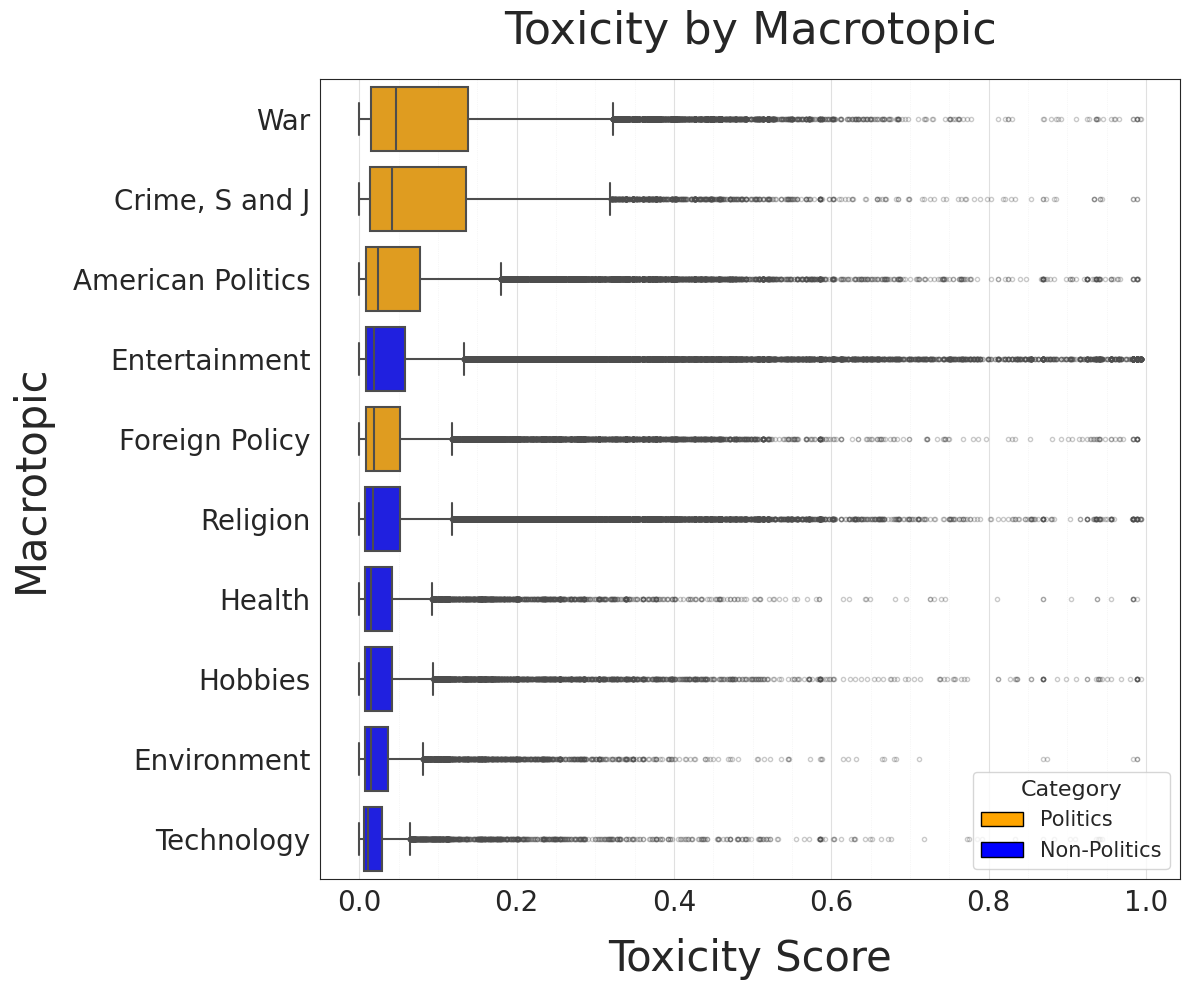

In [ ]:
ordem_decrescente = df.groupby('macrotopic_pred')['perspective_toxicity'].median().sort_values(ascending=False).index

# --- 3. IMPLEMENTAÇÃO DO BOXPLOT PADRONIZADO ---
plt.figure(figsize=(12, 8)) # Aumentado para acomodar labels grandes
sns.set_style("white")

# Invertemos x e y para ficar horizontal e aplicamos a ordem
ax = sns.boxplot(
    x='perspective_toxicity', 
    y='macrotopic_pred', 
    data=df, 
    palette=palette_map, 
    order=ordem_decrescente,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

# --- 4. GRADE VERTICAL (Seguindo o padrão técnico anterior) ---
ax.minorticks_on()
ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.8, color='#d3d3d3', alpha=0.7)
ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, color='#e0e0e0', alpha=0.5)
ax.set_axisbelow(True)

# --- 5. TÍTULOS E EIXOS (Usando o dicionário) ---
plt.title('Toxicity by Macrotopic', **chart_config["titles"])
plt.xlabel('Toxicity Score', **chart_config["xlabels"])
plt.ylabel('Macrotopic', **chart_config["ylabels"])

# Ticks dos eixos (Sem rotação, pois no Y horizontal a leitura é direta)
plt.xticks(**chart_config["xticks"])
plt.yticks(**chart_config["yticks"])

# --- 6. LEGENDA ---
legend_elements = [
    Patch(facecolor='orange', label='Politics', edgecolor='black'),
    Patch(facecolor='blue',   label='Non-Politics', edgecolor='black'),
]
plt.legend(handles=legend_elements, title='Category', loc='lower right', 
           frameon=True, 
           fontsize=chart_config["legend"]["fontsize"], 
           title_fontsize=chart_config["legend"]["title_fontsize"])

plt.tight_layout()

# Salvando em formato vetorial conforme conversamos
plt.savefig("gráficos/boxplot_toxicity_horizontal.svg", format='svg')
plt.show()

/tmp/ipykernel_169935/3732014593.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


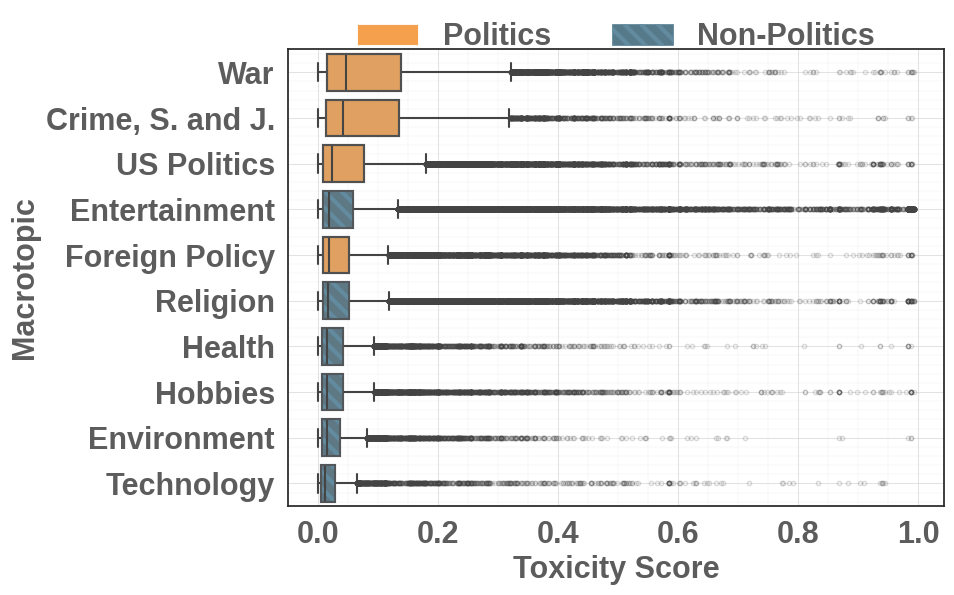

In [11]:
from matplotlib.patches import Patch

ordem_decrescente = (
    df.groupby('macrotopic_pred')['perspective_toxicity']
      .median()
      .sort_values(ascending=False)
      .index
)

plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    x='perspective_toxicity',
    y='macrotopic_pred',
    data=df,
    palette=palette_map,
    order=ordem_decrescente,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.2)
)

for patch, topic in zip(ax.patches, ordem_decrescente):
    if topic in politics:
        #patch.set_hatch('//')      
        #patch.set_edgecolor("#f0b77e")
        i=0
    else:
        patch.set_hatch('\\\\')  
        patch.set_edgecolor('#638b9f')
    patch.set_linewidth(1.5)
    patch.set_zorder(2)

    # borda cinza por cima
    bbox = patch.get_path().get_extents()
    rect = plt.Rectangle(
        (bbox.x0, bbox.y0),
        bbox.x1 - bbox.x0,
        bbox.y1 - bbox.y0,
        linewidth=1.5,
        edgecolor="#525252E6",
        facecolor='none',
        transform=ax.transData,
        zorder=3
    )
    ax.add_patch(rect)


mpl.rcParams['hatch.linewidth'] = 3

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

# rótulos
plt.xlabel('Toxicity Score')
plt.ylabel('Macrotopic')
plt.xticks()
plt.yticks()

legend_elements = [
    Patch(facecolor=palette_map['War'],
          #edgecolor='#f0b77e',
          #hatch='//',
          label='Politics',
          linewidth=0.6),

    Patch(facecolor=palette_map['Religion'],
          edgecolor='#638b9f',
          hatch='\\\\',
          label='Non-Politics',
          linewidth=0.6)
]

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"gráficos/boxplot_toxicity_horizontal.{format}", format=format, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2907340/1587160672.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='macrotopic_pred',


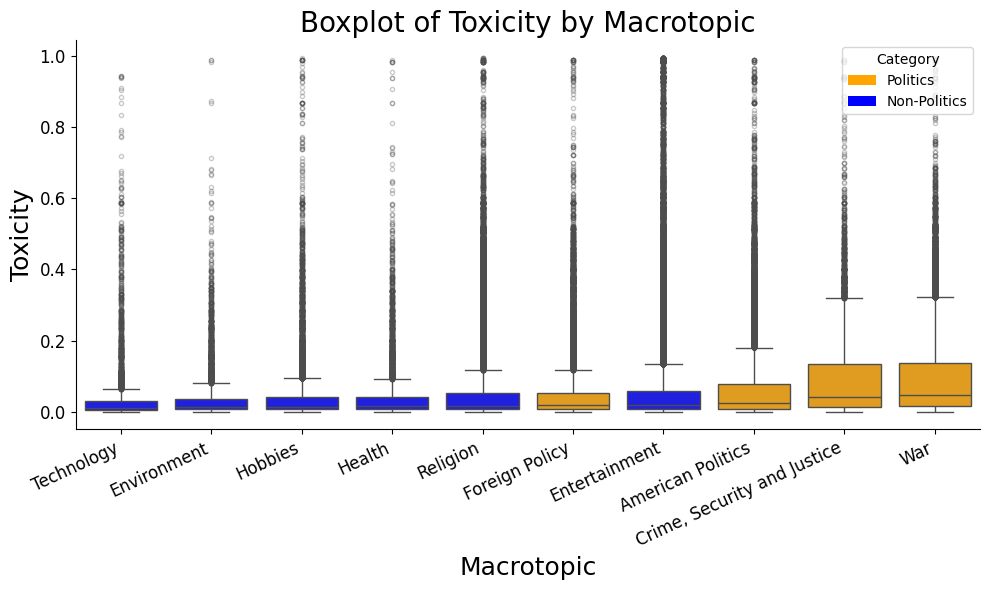

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ordem_crescente = df.groupby('macrotopic_pred')['perspective_toxicity'].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.boxplot(x='macrotopic_pred', 
            y='perspective_toxicity', 
            data=df, 
            palette=palette_map, 
            order=ordem_crescente,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))

plt.title('Boxplot of Toxicity by Macrotopic', fontsize=20)
plt.xlabel('Macrotopic',fontsize=18)
plt.ylabel('Toxicity', fontsize=18)

sns.despine()

legend_elements = [
    Patch(facecolor='orange', label='Politics'),
    Patch(facecolor='blue',   label='Non-Politics'),
]

plt.legend(handles=legend_elements, title='Category', loc='upper right')

plt.xticks(rotation=25, ha='right', size=12) 
plt.yticks(size=12)
plt.tight_layout()
plt.savefig("gráficos/boxplot_toxicity_by_macrotopic") 
plt.show()

In [87]:
stats = df.groupby('macrotopic_pred')['perspective_toxicity'].describe()
tabela_final = stats.T
display(tabela_final.round(3))

macrotopic_pred,"Crime, S. and J.",Entertainment,Environment,Foreign Policy,Health,Hobbies,Religion,Technology,US Politics,War
count,9341.000,110639.000,11500.000,40410.000,11522.000,18913.000,111071.000,8719.000,52998.000,52846.000
mean,0.100,0.066,0.037,0.052,0.042,0.046,0.055,0.036,0.068,0.098
std,0.130,0.126,0.064,0.089,0.076,0.089,0.097,0.079,0.106,0.118
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.014,0.009,0.007,0.008,0.007,0.007,0.008,0.005,0.009,0.015
50%,0.041,0.019,0.014,0.019,0.015,0.015,0.017,0.011,0.023,0.047
75%,0.136,0.059,0.037,0.052,0.041,0.042,0.052,0.029,0.078,0.138
max,0.989,0.994,0.988,0.989,0.988,0.994,0.994,0.945,0.989,0.994


### Matriz

In [8]:
from scipy.stats import mannwhitneyu
import numpy as np

toxicity_per_topic={}


for idx,df_group in df.groupby('macrotopic_pred'):
    toxicity_per_topic[idx]=df_group['perspective_toxicity']

comparison_per_topic={}
mannwithney_test_pairwise=np.zeros((len(toxicity_per_topic),len(toxicity_per_topic)))
ordered_topics=sorted(politics)+sorted(non_politics)
for i,idx1 in enumerate(ordered_topics):
    for j,idx2 in enumerate(ordered_topics):
        if idx1==idx2:
            continue
        test=mannwhitneyu(toxicity_per_topic[idx1].to_list(),toxicity_per_topic[idx2].to_list(),alternative='greater').pvalue
        if test<0.05/81: #Bonferroni Correction: every topic is compared with all the others:  
            print(idx1,idx2,test)
            mannwithney_test_pairwise[i,j]=1
mannwithney_test_pairwise=pd.DataFrame(mannwithney_test_pairwise,index=ordered_topics,columns=ordered_topics)
mannwithney_test_pairwise

Crime, S. and J. Foreign Policy 0.0
Crime, S. and J. US Politics 5.6937223312494755e-176
Crime, S. and J. Entertainment 0.0
Crime, S. and J. Environment 0.0
Crime, S. and J. Health 0.0
Crime, S. and J. Hobbies 0.0
Crime, S. and J. Religion 0.0
Crime, S. and J. Technology 0.0
Foreign Policy Environment 4.420228230774271e-60
Foreign Policy Health 1.7671294933674777e-46
Foreign Policy Hobbies 2.7919442348323967e-49
Foreign Policy Religion 1.4192620513589319e-12
Foreign Policy Technology 4.291561217362917e-178
US Politics Foreign Policy 1.1344066349051939e-131
US Politics Entertainment 2.965974402759845e-84
US Politics Environment 4.094143767634726e-226
US Politics Health 5.513530653609741e-193
US Politics Hobbies 4.3893841067424745e-248
US Politics Religion 2.0581602880892954e-295
US Politics Technology 0.0
War Crime, S. and J. 0.00012825247506006082
War Foreign Policy 0.0
War US Politics 0.0
War Entertainment 0.0
War Environment 0.0
War Health 0.0
War Hobbies 0.0
War Religion 0.0
War Tec

,"Crime, S. and J.",Foreign Policy,US Politics,War,Entertainment,Environment,Health,Hobbies,Religion,Technology
"Crime, S. and J.",0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Foreign Policy,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
US Politics,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
War,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
Entertainment,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Environment,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Hobbies,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Religion,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
Technology,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
ordered=mannwithney_test_pairwise.sum(axis=1).sort_values(ascending=False).index
ordered=['War', 'Crime, S. and J.', 'US Politics', 'Foreign Policy','Entertainment', 'Religion', 'Hobbies', 'Environment','Health', 'Technology']
ordered_inv = ordered[::-1]

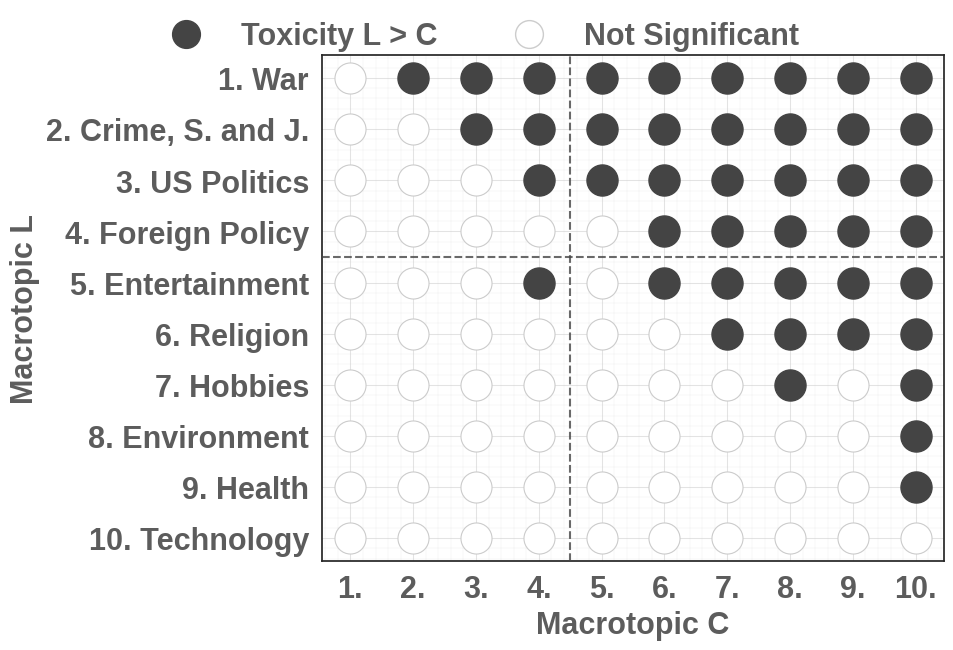

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

data = mannwithney_test_pairwise.loc[ordered, ordered]

for i, row in enumerate(ordered):
    for j, col in enumerate(ordered):
        if data.loc[row, col] == 1:
            ax.scatter(j, i, s=500, color='#444444', zorder=3)
        else:
            ax.scatter(j, i, s=500, color='white', edgecolors='#cccccc', linewidth=0.8, zorder=2)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444',
           markeredgecolor='#444444', markersize=20, label='Toxicity L > C'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
           markeredgecolor='#cccccc', markersize=20, label='Not Significant')
]

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xticks(range(len(ordered)))
ax.set_xticklabels([f"{i}." for i in range(1, len(ordered) + 1)], rotation=0)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels([f"{i+1}. {name}" for i, name in enumerate(ordered)])
ax.invert_yaxis()
ax.set_ylabel("Macrotopic L")
ax.set_xlabel("Macrotopic C")

leg = fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.50, 0.97),
    ncol=2,
    frameon=False
)

ax.axhline(y=3.5, color='#444444', linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)
ax.axvline(x=3.5, color='#444444', linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f"gráficos/bubble_mannwhitney.{format}", format=format, bbox_inches='tight')
plt.show()

___
## **RQ2 Analisando a Difusão de vídeos políticos pelo Telegram**

In [8]:
interest = ['War','US Politics','Foreign Policy','Crime, S. and J.','Health','Religion','Hobbies'
    #,"Technology","Environment","Entertainment"
    ]
df = df_all[df_all["macrotopic_pred"].isin(interest)]
df_complete = df_complete[df_complete["macrotopic_pred"].isin(interest)]

#### *Correlação de Spearman*

In [10]:
from scipy.stats import spearmanr
def spearman_by_topic(df_topic, col_pivo ,cols):
    results = {}

    for col in cols:
        tmp = df_topic[[col_pivo, col]].dropna()

        rho, p = spearmanr(tmp[col_pivo], tmp[col])

        results[col] = {
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        }

    return results

In [11]:
def apply_spearman_correlation(df, col_pivo, cols):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        topic_results = spearman_by_topic(df_topic, col_pivo, cols)

        for metric, values in topic_results.items():
            all_results.append({
                'macrotopic_pred': topic,
                'metric': metric,
                'spearman_rho': values['spearman_rho'],
                'p_value': values['p_value'], 
                'n': values['n']
            })

    results_df = pd.DataFrame(all_results)

    # Tabela 1: Força da Correlação (Rho)
    pivot_rho = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='spearman_rho'
    ).sort_index()
    
    # Tabela 2: Significância Estatística (P-valor)
    pivot_p = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='p_value'
    ).sort_index()

    return pivot_rho, pivot_p

#### **1. toxicidade x métricas**

In [13]:
df_analise_canal = df_complete.groupby("video_id").agg({
    "folder": "nunique",
    "perspective_toxicity": "mean",
    "perspective_identity_attack": "mean",
    "perspective_insult": "mean",
    "perspective_obscene": "mean",
    "perspective_severe_toxicity": "mean",
    "perspective_threat": "mean",
    "macrotopic_pred": "first",
}).reset_index()

In [14]:
ordem_desejada = [
    "War",
    "Crime, S. and J.",
    "US Politics",
    "Foreign Policy",
    "Religion",
    "Hobbies",
    "Health"
]


Text(1.02, 0.5, '1. War\n2. Crime, S. and J.\n3. US Politics\n4. Foreign Policy\n5. Religion\n6. Hobbies\n7. Health')

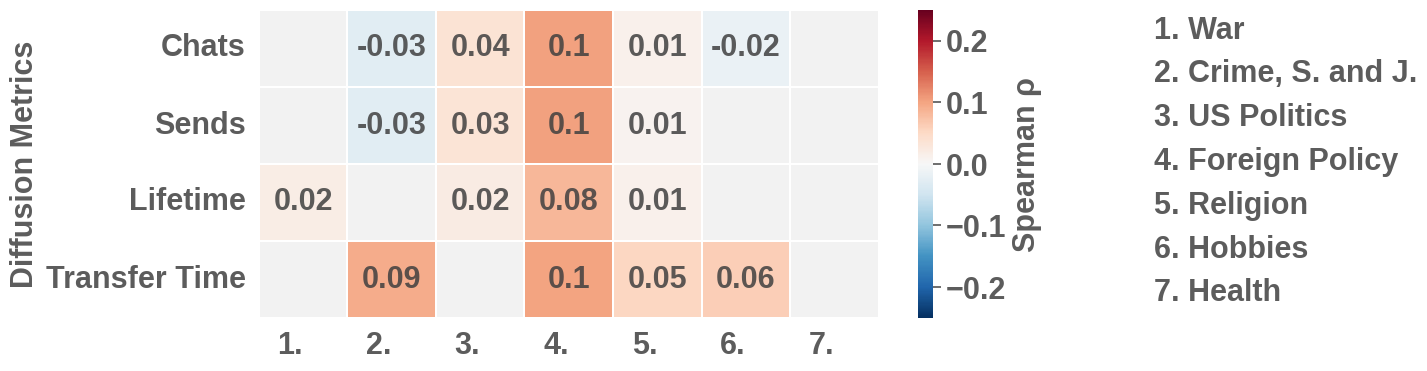

In [82]:
def apply_spearman_single(df, col_pivo, tox_col='perspective_toxicity'):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        tmp = df_topic[[col_pivo, tox_col]].dropna()

        if len(tmp) > 1:
            rho, p = spearmanr(tmp[col_pivo], tmp[tox_col])
        else:
            rho, p = None, None

        all_results.append({
            'macrotopic_pred': topic,
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        })

    results_df = pd.DataFrame(all_results)

    # agora vira uma série (não precisa pivot)
    rho_series = results_df.set_index('macrotopic_pred')['spearman_rho'].sort_index()
    p_series = results_df.set_index('macrotopic_pred')['p_value'].sort_index()

    return rho_series, p_series

dados_heatmap = []
pvalues_heatmap = []

metricas = [
    ('Chats', df_analise_canal, 'folder'),
    ('Sends', df, 'send_count'),
    ('Lifetime', df, 'lifetime'),
    ('Transfer Time', df, 'transfer_time')
]

for nome, dataframe, col in metricas:
    rho, p = apply_spearman_single(dataframe, col)
    
    rho = rho.reindex(ordem_desejada)
    p = p.reindex(ordem_desejada)

    dados_heatmap.append(rho)
    pvalues_heatmap.append(p)

heatmap_df = pd.DataFrame(dados_heatmap, index=[m[0] for m in metricas])
pvalues_df = pd.DataFrame(pvalues_heatmap, index=[m[0] for m in metricas])

plot_heatmap(
    heatmap_df,
    p_values=pvalues_df,
    title=None,
    vmin=-0.25,
    vmax=0.25,
    ylabel="Diffusion Metrics"
)

ax = plt.gca()

ax.set_xticklabels(
    [f"{i}." for i in range(1, len(ordem_desejada) + 1)],
    rotation=0
)

mapping = {i+1: topic for i, topic in enumerate(ordem_desejada)}

legend_text = "\n".join([f"{i}. {topic}" for i, topic in mapping.items()])

fig = plt.gcf()
fig.set_size_inches(10,4)

#plt.title('Toxicity vs Diffusion Metrics')
fig.text(
    1.02, 0.5,   
    legend_text,
    ha='left',
    va='center',
    linespacing=1.6
)

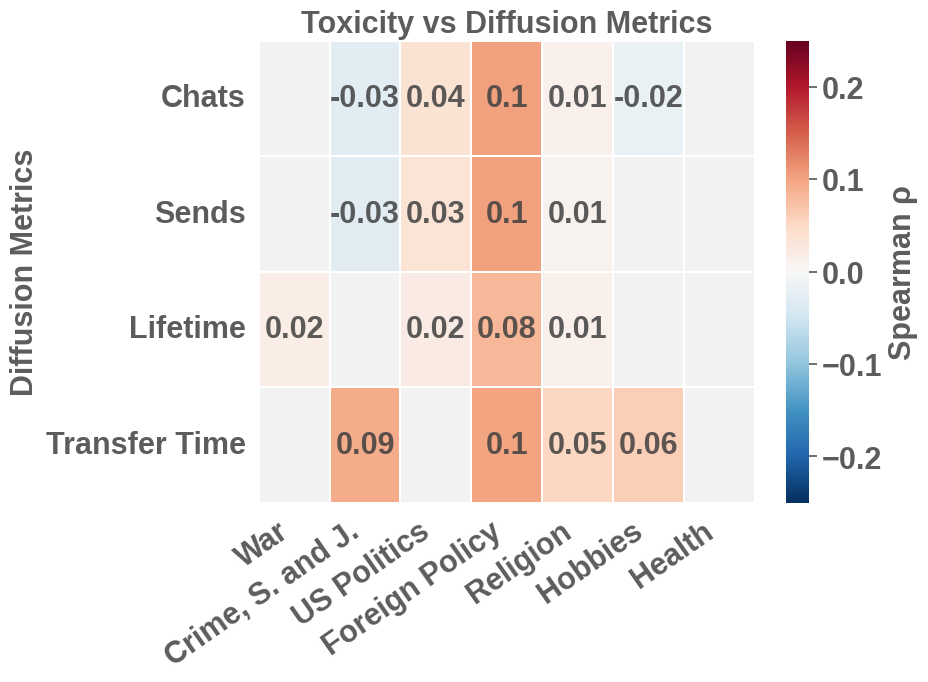

In [ ]:
def apply_spearman_single(df, col_pivo, tox_col='perspective_toxicity'):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        tmp = df_topic[[col_pivo, tox_col]].dropna()

        if len(tmp) > 1:
            rho, p = spearmanr(tmp[col_pivo], tmp[tox_col])
        else:
            rho, p = None, None

        all_results.append({
            'macrotopic_pred': topic,
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        })

    results_df = pd.DataFrame(all_results)

    # agora vira uma série (não precisa pivot)
    rho_series = results_df.set_index('macrotopic_pred')['spearman_rho'].sort_index()
    p_series = results_df.set_index('macrotopic_pred')['p_value'].sort_index()

    return rho_series, p_series

dados_heatmap = []
pvalues_heatmap = []

metricas = [
    ('Chats', df_analise_canal, 'folder'),
    ('Sends', df, 'send_count'),
    ('Lifetime', df, 'lifetime'),
    ('Transfer Time', df, 'transfer_time')
]

for nome, dataframe, col in metricas:
    rho, p = apply_spearman_single(dataframe, col)
    
    rho = rho.reindex(ordem_desejada)
    p = p.reindex(ordem_desejada)

    dados_heatmap.append(rho)
    pvalues_heatmap.append(p)

heatmap_df = pd.DataFrame(dados_heatmap, index=[m[0] for m in metricas])
pvalues_df = pd.DataFrame(pvalues_heatmap, index=[m[0] for m in metricas])

plot_heatmap(
    heatmap_df,
    title='Toxicity vs Diffusion Metrics',
    p_values=pvalues_df,
    vmin=-0.25,
    vmax=0.25,
    ylabel="Diffusion Metrics"
)


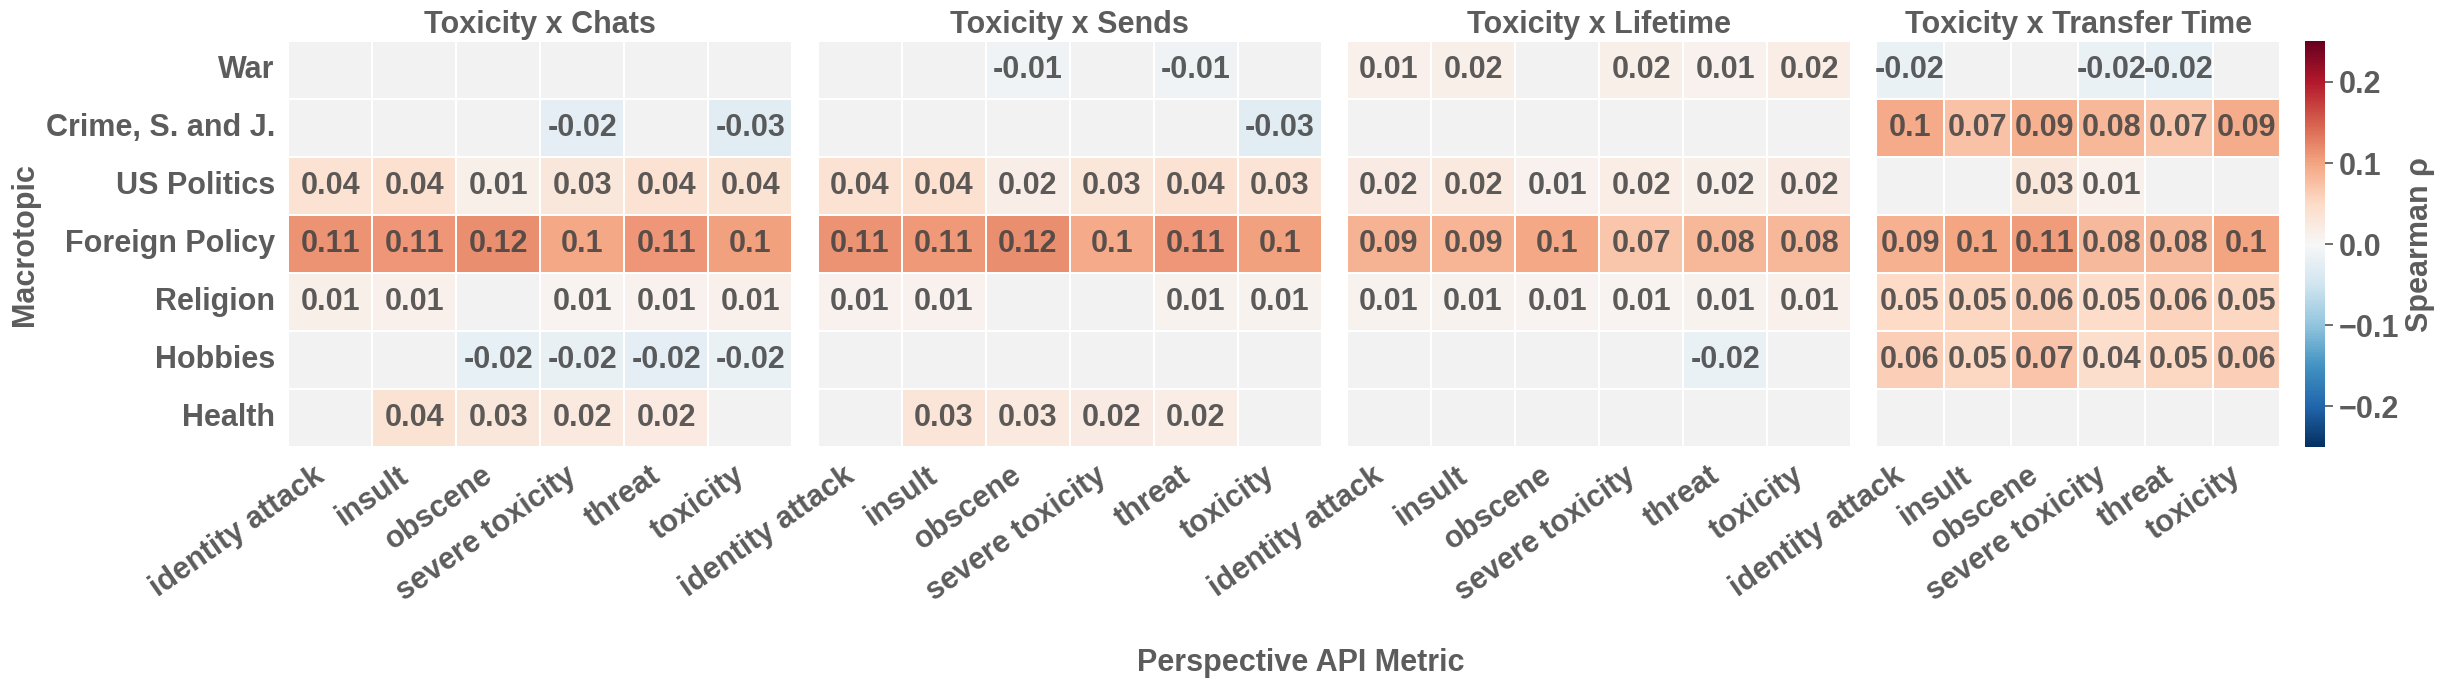

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(27, 7), gridspec_kw={'width_ratios': [1, 1, 1, 1]})
fig.subplots_adjust(wspace=0.05)  # cola os gráficos

# --- GRÁFICO 1 ---
rho, p_vals = apply_spearman_correlation(df_analise_canal, 'folder', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Chats', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[0], cbar=False)

# --- GRÁFICO 2 ---
rho, p_vals = apply_spearman_correlation(df, 'send_count', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Sends', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[1], cbar=False, ylabel="")

# --- GRÁFICO 3 ---
rho, p_vals = apply_spearman_correlation(df, 'lifetime', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Lifetime', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[2], cbar=False, ylabel="")

# --- GRÁFICO 4 ---
rho, p_vals = apply_spearman_correlation(df, 'transfer_time', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)
plot_heatmap(rho, 'Toxicity x Transfer Time', p_values=p_vals, vmin=-0.25, vmax=0.25, ax=axs[3], cbar=True, yticks=False, ylabel="")

# remove yticks dos gráficos 2 e 3
axs[1].tick_params(labelleft=False)
axs[2].tick_params(labelleft=False)

# xlabel centralizado único
fig.subplots_adjust(wspace=0.05, bottom=0.30)

# xlabel centralizado único - ajuste o y conforme necessário
fig.text(0.5, -0.02, 'Perspective API Metric', ha='center')

plt.savefig(f"gráficos/spearman_heatmap.{format}", format=format, bbox_inches='tight')
plt.show()

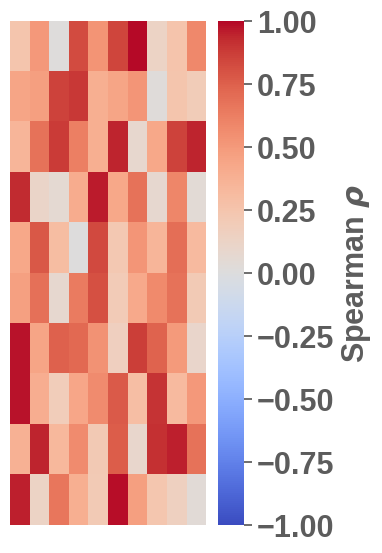

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# dados aleatórios
data = np.random.rand(10, 10)

plt.figure(figsize=(4,6))

ax = sns.heatmap(
    data,
    cmap="coolwarm",   # use o mesmo cmap do seu heatmap
    vmin=-1,
    vmax=1,
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

cbar = ax.collections[0].colorbar
cbar.set_label(r"Spearman $\rho$")

plt.tight_layout()

plt.savefig("colorbar_heatmap.png", dpi=300)
plt.show()

### Gráficos cumulativos

In [9]:
df_resumo = df_complete.groupby('video_id').agg({
    'lifetime': 'first',               
    'send_count': 'first',            
    'folder': 'nunique',
    'transfer_time': 'first',                   
    'macrotopic_pred': 'first',             
    'perspective_toxicity': 'mean'         
}).reset_index()

df_resumo.columns = ['video_id', 'lifetime', 'send_count', 'groups', 'transfer_time', 'macrotopic_pred', 'perspective_toxicity']
display(df_resumo.head())

,video_id,lifetime,send_count,groups,transfer_time,macrotopic_pred,perspective_toxicity
0,---HJCJANEk,1.0,1,1,1937.0,Religion,0.023995
1,--0HDiV4Wrk,1.0,1,1,85.0,Foreign Policy,0.005799
2,--0WrRVhu20,1.0,10,9,0.0,"Crime, S. and J.",0.008402
3,--0jTye5wh4,1.0,1,1,0.0,Religion,0.007362
4,--0o49GFj4U,1.0,1,1,0.0,Religion,0.004463


In [10]:
print(df_resumo['macrotopic_pred'].value_counts())
len(df_resumo)

macrotopic_pred
Religion            111071
US Politics          52998
War                  52846
Foreign Policy       40410
Hobbies              18913
Health               11522
Crime, S. and J.      9341
Name: count, dtype: int64


297101

In [11]:
# 1. Printar a distribuição por tópico (como você já estava fazendo)
print("Distribuição por tópico (envio único):")
print(df_resumo['macrotopic_pred'][df_resumo['send_count'] == 1].value_counts())

print("-" * 30)

# 2. Printar a quantidade TOTAL apenas uma vez
total_envio_unico = len(df_resumo[df_resumo['send_count'] == 1])
print(f"Total de vídeos com apenas 1 envio: {total_envio_unico}")

print(f"Vídeos que foram enviados mais de uma vez: {len(df_resumo) - total_envio_unico}")

Distribuição por tópico (envio único):
macrotopic_pred
Religion            64947
War                 33570
Foreign Policy      28580
US Politics         24819
Hobbies             13985
Health               6740
Crime, S. and J.     4094
Name: count, dtype: int64
------------------------------
Total de vídeos com apenas 1 envio: 176735
Vídeos que foram enviados mais de uma vez: 120366


78% dos vídeos são enviados apenas 1 vez, portanto tendo o alcance equivalente independente do tópico

In [12]:
df_resumo['Politics']=df_resumo['macrotopic_pred'].apply(lambda x: x in politics)
df_politics=df_resumo[df_resumo['Politics']].copy()
df_non_politics=df_resumo[~df_resumo['Politics']].copy()

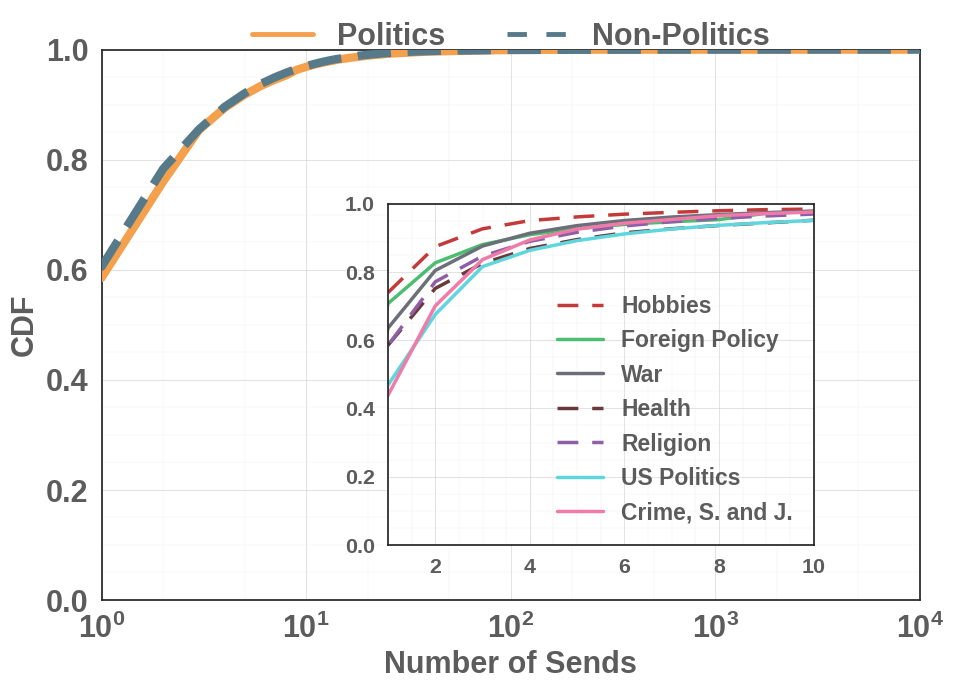

In [13]:
import numpy as np
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

value = 'send_count'

# Politics
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['War'], linestyle='solid', linewidth=6.0, zorder=3, label='Politics')

# Non-politics
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['Religion'], linestyle=(0, (4, 2)), linewidth=6.0, zorder=3, label='Non-Politics')

ax.set_xscale('log')
ax.set_xlim(1, 10000)
ax.set_ylim(0, 1)

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xlabel('Number of Sends')
ax.set_ylabel('CDF')

# =======================
# INSET — canto inferior direito
# =======================
axin = ax.inset_axes([0.35, 0.1, 0.52, 0.62])

axin.set_axisbelow(True)
axin.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
axin.minorticks_on()
axin.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ponto_ordenacao = 1
ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x <= ponto_ordenacao).mean()
)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:
    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([(x_sorted <= v).sum() / n for v in xs])
    linestyle = 'solid' if idx in politics else (0, (6, 4))
    axin.plot(xs, y, color=macro_colors[idx], linewidth=2.5, linestyle=linestyle, label=idx)

axin.set_xlim(1, 10)
axin.set_ylim(0, 1)
axin.set_ylabel('')
axin.set_facecolor('white')
axin.tick_params(labelsize=plt.rcParams['font.size'] * 0.7)
axin.legend(fontsize=plt.rcParams['font.size'] * 0.75, frameon=False, loc='lower right')

# Legenda global
legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)), label='Non-Politics'),
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 1.05])
plt.savefig(f"gráficos/cdf_sends.{format}", format=format, dpi=300, bbox_inches='tight')
plt.show()

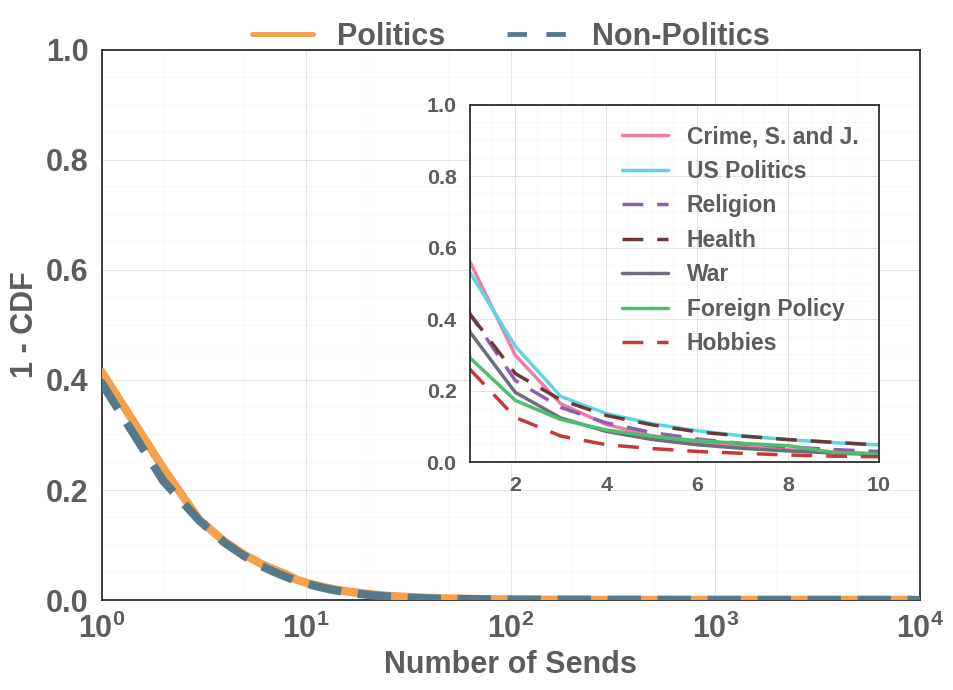

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))

value = 'send_count'

# --- Política ---
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
# Mudança aqui: 1 - proporção acumulada
y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs]) 
ax.plot(xs, y, color=palette_map['War'], linestyle='solid', linewidth=6.0, zorder=3, label='Politics')

# --- Não-Política ---
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
# Mudança aqui: 1 - proporção acumulada
y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs])
ax.plot(xs, y, color=palette_map['Religion'], linestyle=(0, (4, 2)), linewidth=6.0, zorder=3, label='Non-Politics')

# Escala e Limites
ax.set_xscale('log')
# Para CCDFs de cauda longa, geralmente usa-se log no eixo Y também. 
# Se preferir linear, mantenha como está. Se quiser log-log, use: ax.set_yscale('log')
ax.set_xlim(1, 10000)
ax.set_ylim(0, 1) # Se usar log no Y, mude o limite inferior para algo como 1e-4

ax.set_axisbelow(True)
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.05))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ax.set_xlabel('Number of Sends')
ax.set_ylabel('1 - CDF') # Rótulo alterado

# =======================
# INSET — canto superior direito (ajustado para CCDF costuma ficar melhor no topo)
# =======================
# Ajustei as coordenadas do inset [x, y, largura, altura] para não sobrepor as linhas
axin = ax.inset_axes([0.45, 0.25, 0.50, 0.65])

axin.set_axisbelow(True)
axin.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
axin.minorticks_on()
axin.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

ponto_ordenacao = 1
# A lógica de ordenação pode permanecer a mesma ou ser invertida dependendo do seu interesse
ponto_inicial = 1
ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x > ponto_inicial).mean()
)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:
    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    # Mudança aqui: 1 - proporção acumulada
    y = 1 - np.array([(x_sorted <= v).sum() / n for v in xs])
    linestyle = 'solid' if idx in politics else (0, (6, 4))
    axin.plot(xs, y, color=macro_colors[idx], linewidth=2.5, linestyle=linestyle, label=idx)

axin.set_xlim(1, 10)
axin.set_ylim(0, 1)
axin.set_ylabel('')
axin.set_facecolor('white')
axin.tick_params(labelsize=plt.rcParams['font.size'] * 0.7)
axin.legend(fontsize=plt.rcParams['font.size'] * 0.75, frameon=False, loc='upper right')

# Legenda global
legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)), label='Non-Politics'),
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 1.05])
plt.savefig(f"gráficos/ccdf_sends.{format}", format=format, dpi=300, bbox_inches='tight')
plt.show()

Portanto a massa dos vídeos tem um poder de difusão similar, uma característica de 1 envio, 1 canal, 1 dia
Vamos analisar agora os vídeos com quantidade de envio maior do que 2 para ver se quando um vídeo é repetido isso difere

In [25]:
df_resumo = df_resumo[df_resumo['send_count'] > 1].copy()
len(df_resumo)
df_politics=df_resumo[df_resumo['Politics']].copy()
df_non_politics=df_resumo[~df_resumo['Politics']].copy()

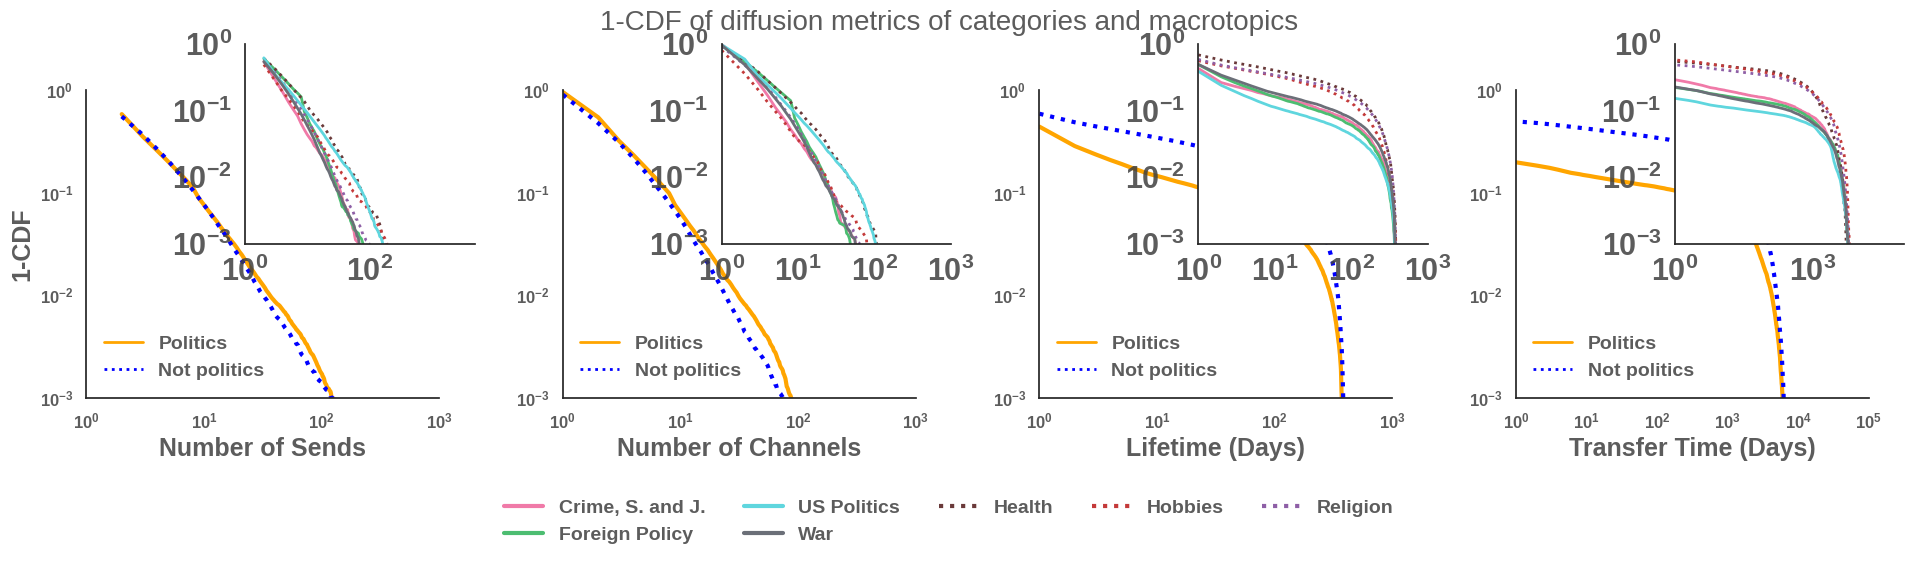

In [26]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from collections import Counter
from matplotlib.lines import Line2D

fig, axs = plt.subplots(figsize=(23, 4),ncols=4)
fig.subplots_adjust(wspace=0.35)

to_plot=['send_count','groups','lifetime','transfer_time']

macros_used = sorted(df_resumo['macrotopic_pred'].unique())

axins=[]

for ax,value in zip(axs,to_plot):
    
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs
            , y
            ,'orange'
            ,linestyle='solid'
            ,linewidth=3)
    
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs 
            , y
            ,'blue'
            ,linestyle='dotted'
            ,linewidth=3)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    legend_elements = [
        Line2D([0], [0], color='orange', lw=2, linestyle='-',
               label='Politics'),
        Line2D([0], [0], color='blue', lw=2, linestyle='dotted',
               label='Not politics')
    ]
    
     
    ax.legend( handles=legend_elements,
        fontsize=14,
        frameon=False,
        loc='lower left')

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    axin = inset_axes(
        ax,
        width="65%",     # dimensione relativa
        height="65%",
        loc='upper right',
        borderpad=0,
        bbox_to_anchor=(0.1, 0.15, 1, 1),  # x > 1 
        bbox_transform=ax.transAxes
    )

    for idx,df_group in df_resumo.groupby('macrotopic_pred'):
        lines=[]
        linestyle = 'solid' if idx in politics else 'dotted'

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)
        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
        line = axin.plot(xs,
                        y,
                        label=idx,
                        c=macro_colors[idx],
                        linewidth=2,
                        linestyle=linestyle)

        lines.append(line)

        
    axin.set_xscale('log')
    axin.set_yscale('log')

    axin.spines['right'].set_visible(False)
    axin.spines['top'].set_visible(False)
    
    axins.append(axin)

ordered_macros = (
    [m for m in macros_used if m in politics] +
    [m for m in macros_used if m not in politics]
)
legend_elements = [
    Line2D([0], [0], color=macro_colors[idx], lw=3, linestyle='solid' if idx in politics else 'dotted',
           label=idx)
        for idx in ordered_macros]

axs[0].set_xlim(1,1000)
axs[0].set_ylim(1e-3,1)
axs[0].set_xlabel('Number of Sends',fontsize=18)
axs[0].set_ylabel('1-CDF',fontsize=18)
axins[0].set_xlim(1,5000)
axins[0].set_ylim(1e-3,1)


axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-3,1)
axs[1].set_xlabel('Number of Channels',fontsize=18)
axins[1].set_xlim(1,1000)
axins[1].set_ylim(1e-3,1)


axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-3,1)
axs[2].set_xlabel('Lifetime (Days)',fontsize=18)
axins[2].set_xlim(1,1000)
axins[2].set_ylim(1e-3,1)

axs[3].set_xlim(1, 100000) 
axs[3].set_ylim(1e-3, 1)
axs[3].set_xlabel('Transfer Time (Days)',fontsize=18)
axins[3].set_xlim(1,100000)
axins[3].set_ylim(1e-3,1)

fig.suptitle(
    '1-CDF of diffusion metrics of categories and macrotopics',
    fontsize=20,
    y=1.08
)
fig.legend(handles=legend_elements,
            loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.3)
)
    
plt.savefig("gráficos/ecdf_category_topic.png", bbox_inches='tight')

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="white",
    font="Liberation Sans"
)

plt.rcParams.update({
    'font.family': 'Liberation Sans',

    # fontes escaladas para figuras largas (~27 width)
    'font.size': 34,
    'axes.titlesize': 36,
    'axes.labelsize': 36,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'legend.fontsize': 34,
    'figure.titlesize': 36,

    'text.color': "#3F3F3FD8",
    'axes.labelcolor': "#3F3F3FD8",
    'xtick.color': "#3F3F3FD8",
    'ytick.color': "#3F3F3FD8",

    'font.weight': 700,
    'axes.labelweight': 700,
    'axes.titleweight': 700,
})

format = 'png'

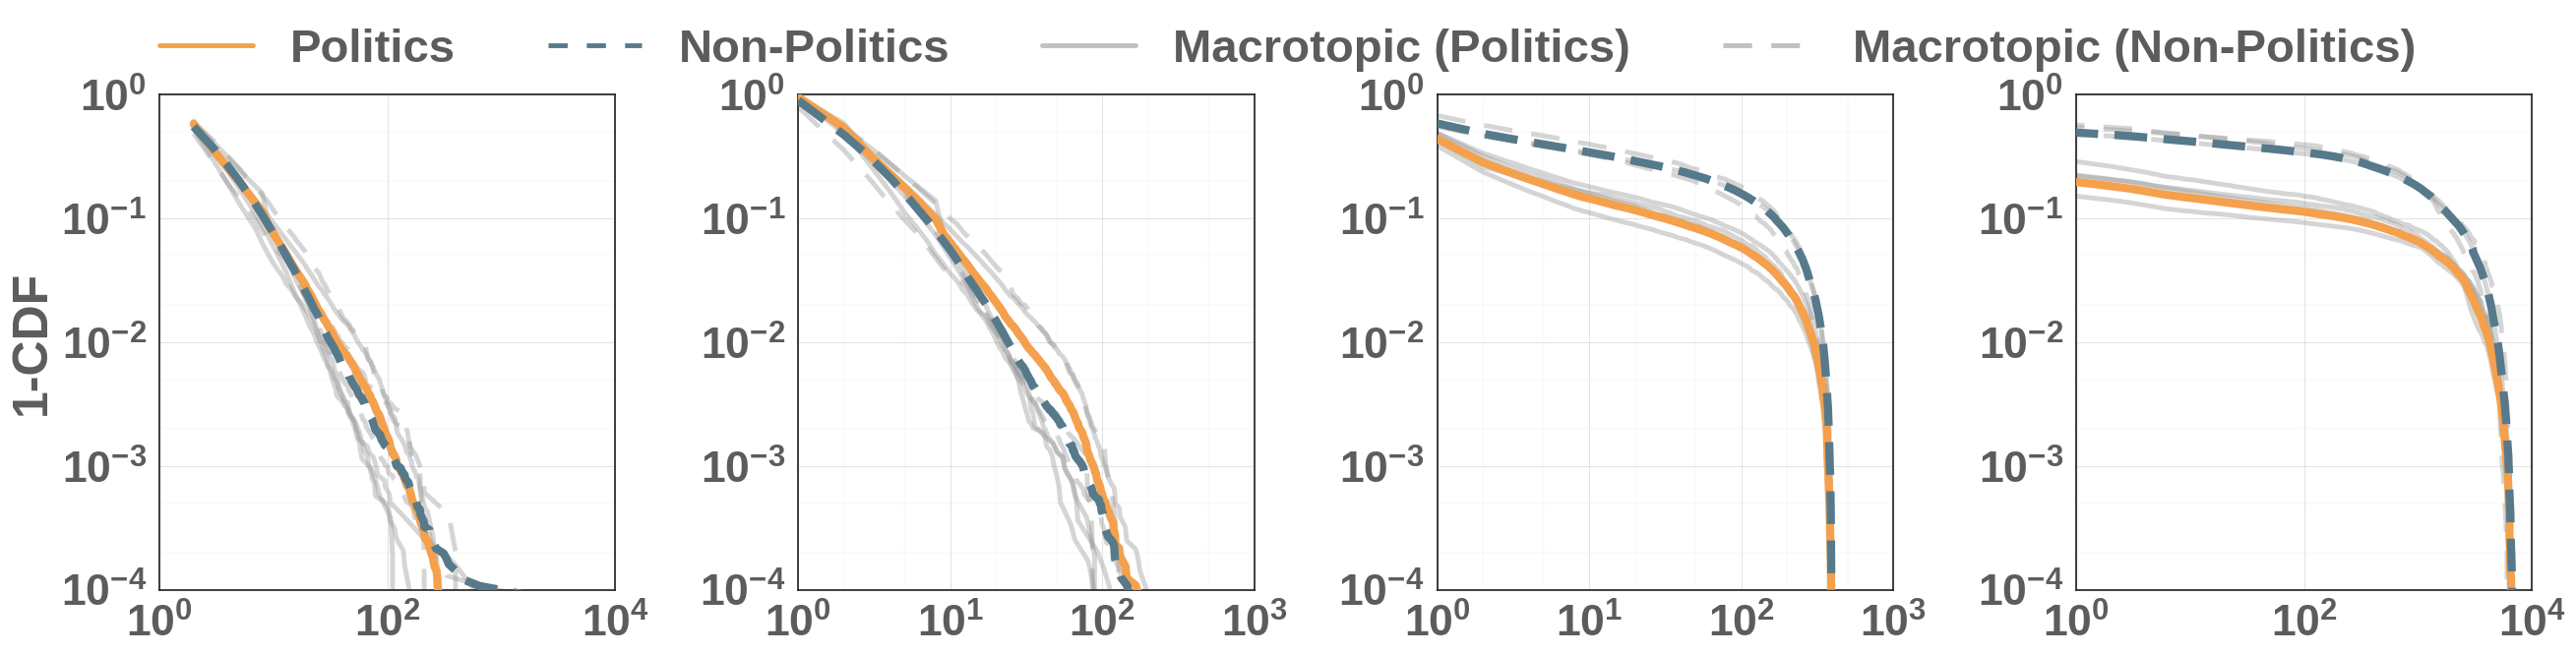

In [30]:
from matplotlib.lines import Line2D
import numpy as np

fig, axs = plt.subplots(figsize=(27, 7), ncols=4)
#fig.subplots_adjust(wspace=0.35)

to_plot = ['send_count','groups','lifetime','transfer_time']
macros_used = sorted(df_resumo['macrotopic_pred'].unique())

for ax, value in zip(axs, to_plot):
    # -------------------------------
    # Macrotópicos (apagados)
    # -------------------------------
    for idx, df_group in df_resumo.groupby('macrotopic_pred'):

        linestyle = (0, (6, 4)) if idx not in politics else 'solid'  

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)

        if n == 0:
            continue

        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

        ax.plot(
            xs, y,
            color="#979696",   
            linewidth=3.5,
            linestyle=linestyle,
            alpha=0.4,       
            zorder=1
        )

    # -------------------------------
    # Categoria: politics (forte)
    # -------------------------------
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color=palette_map['War'],
        linestyle='solid',
        linewidth=6.0,
        alpha=1.0,
        zorder=3
    )

    # -------------------------------
    # Categoria: non-politics (forte)
    # -------------------------------
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color=palette_map['Religion'],
        linestyle=(0, (4, 2)),  
        linewidth=6.0,
        alpha=1.0,
        zorder=3
    )

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_axisbelow(True)

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.yaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
    ax.xaxis.set_minor_locator(plt.LogLocator(base=10, subs=[2, 5]))
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

# -------------------------------
# Limites e labels
# -------------------------------
axs[0].set_xlim(1,10000)
axs[0].set_ylim(1e-4,1)
#axs[0].set_xlabel('a.) Number of Sends')
axs[0].set_ylabel('1-CDF')

axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-4,1)
#axs[1].set_xlabel('b.) Number of Chats')

axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-4,1)
#axs[2].set_xlabel('c.) Lifetime (Days)')

axs[3].set_xlim(1,10000)
axs[3].set_ylim(1e-4,1)
#axs[3].set_xlabel('d.) Transfer Time (Days)')

legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid',
           label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)),
           label='Non-Politics'),
    Line2D([0], [0], color="#979696", lw=3.5, linestyle='solid', alpha=0.6,
           label='Macrotopic (Politics)'),
    Line2D([0], [0], color="#979696", lw=3.5, linestyle=(0, (6, 4)), alpha=0.6,
           label='Macrotopic (Non-Politics)'),
]

fig.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=4,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(f"gráficos/ecdf_category_topic2.{format}",format=format, dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_386928/385165691.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_politics['intensidade_disparo'] = df_politics['send_count'] / df_politics['lifetime']
/tmp/ipykernel_386928/385165691.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_politics['velocidade_expansao'] = df_politics['groups'] / df_politics['lifetime']
/tmp/ipykernel_386928/385165691.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

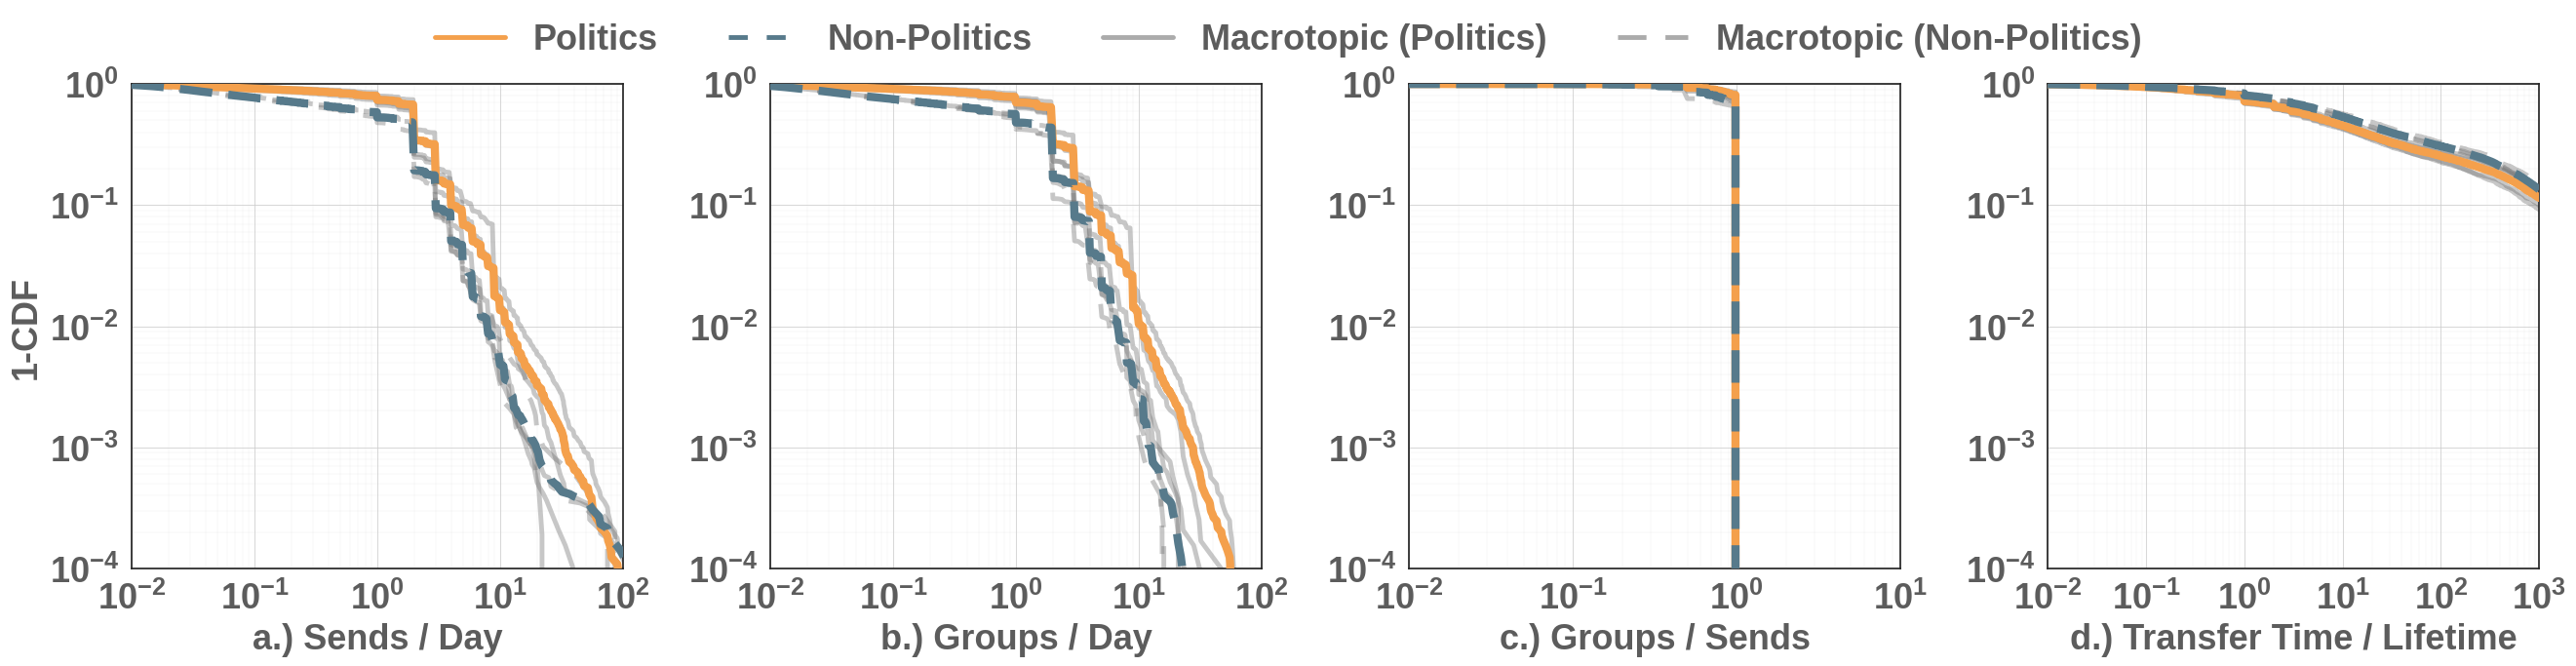

In [18]:
from matplotlib.lines import Line2D

# Métricas derivadas
df_resumo['intensidade_disparo'] = df_resumo['send_count'] / df_resumo['lifetime']
df_resumo['velocidade_expansao'] = df_resumo['groups'] / df_resumo['lifetime']
df_resumo['taxa_espalhamento']   = df_resumo['groups'] / df_resumo['send_count']
df_resumo['transfer_lifetime']   = df_resumo['transfer_time'] / df_resumo['lifetime']

df_politics['intensidade_disparo'] = df_politics['send_count'] / df_politics['lifetime']
df_politics['velocidade_expansao'] = df_politics['groups'] / df_politics['lifetime']
df_politics['taxa_espalhamento']   = df_politics['groups'] / df_politics['send_count']
df_politics['transfer_lifetime']   = df_politics['transfer_time'] / df_politics['lifetime']

df_non_politics['intensidade_disparo'] = df_non_politics['send_count'] / df_non_politics['lifetime']
df_non_politics['velocidade_expansao'] = df_non_politics['groups'] / df_non_politics['lifetime']
df_non_politics['taxa_espalhamento']   = df_non_politics['groups'] / df_non_politics['send_count']
df_non_politics['transfer_lifetime']   = df_non_politics['transfer_time'] / df_non_politics['lifetime']

to_plot = ['intensidade_disparo', 'velocidade_expansao', 'taxa_espalhamento', 'transfer_lifetime']

labels = {
    'intensidade_disparo': 'a.) Sends / Day',
    'velocidade_expansao': 'b.) Groups / Day',
    'taxa_espalhamento':   'c.) Groups / Sends',
    'transfer_lifetime':   'd.) Transfer Time / Lifetime',
}

xlims = {
    'intensidade_disparo': (1e-2, 100),
    'velocidade_expansao': (1e-2, 100),
    'taxa_espalhamento':   (1e-2, 10),
    'transfer_lifetime':   (1e-2, 1000),
}

fig, axs = plt.subplots(figsize=(27, 7), ncols=4)

for ax, value in zip(axs, to_plot):
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

    # Macrotópicos
    for idx, df_group in df_resumo.groupby('macrotopic_pred'):
        linestyle = (0, (6, 4)) if idx not in politics else 'solid'
        df_group = df_group[df_group[value] > 0]
        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)
        if n == 0:
            continue
        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
        ax.plot(xs, y, color="#747474", linewidth=3.5, linestyle=linestyle, alpha=0.4, zorder=1)

    # Politics
    d = df_politics[df_politics[value] > 0]
    x_sorted = d[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
    ax.plot(xs, y, color=palette_map['War'], linestyle='solid', linewidth=6.0, alpha=1.0, zorder=3)

    # Non-politics
    d = df_non_politics[df_non_politics[value] > 0]
    x_sorted = d[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
    ax.plot(xs, y, color=palette_map['Religion'], linestyle=(0, (4, 2)), linewidth=6.0, alpha=1.0, zorder=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(*xlims[value])
    ax.set_ylim(1e-4, 1)
    ax.set_xlabel(labels[value])

axs[0].set_ylabel('1-CDF')

legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=3.5, linestyle=(0, (4, 4)), label='Non-Politics'),
    Line2D([0], [0], color="#747474", lw=3.5, linestyle='solid', alpha=0.6, label='Macrotopic (Politics)'),
    Line2D([0], [0], color="#747474", lw=3.5, linestyle=(0, (6, 4)), alpha=0.6, label='Macrotopic (Non-Politics)'),
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("gráficos/ecdf_derived_metrics.png", bbox_inches='tight')
plt.show()

In [18]:
dfs = [df_resumo, df_politics, df_non_politics]

for df in dfs:
    df['intensidade_disparo'] = df['send_count'] / df['lifetime']
    df['velocidade_expansao'] = df['groups'] / df['lifetime']
    df['taxa_espalhamento']   = df['groups'] / df['send_count']
    df['transfer_lifetime']   = df['transfer_time'] / df['lifetime']
    df['send_transfer'] = df['send_count'] / (df['transfer_time'] + 1)

In [19]:
import pandas as pd
from scipy.stats import mannwhitneyu

metrics = {
    'Sends / Day':              'intensidade_disparo',
    'Groups / Day':             'velocidade_expansao',
    'Groups / Sends':           'taxa_espalhamento',
    'Sends / Transfer Time':    'send_transfer',
}

rows = []
for label, col in metrics.items():
    p   = df_politics[col].replace([np.inf, -np.inf], np.nan).dropna()
    np_ = df_non_politics[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    stat, pval = mannwhitneyu(p, np_, alternative='two-sided')
    
    rows.append({
        'Metric':              label,
        'Politics Mean':       f"{p.mean():.3f}",
        'Politics Std':        f"{p.std():.3f}",
        'Politics Median':     f"{p.median():.3f}",
        'Non-Politics Mean':   f"{np_.mean():.3f}",
        'Non-Politics Std':    f"{np_.std():.3f}",
        'Non-Politics Median': f"{np_.median():.3f}"
    })

df_table = pd.DataFrame(rows).set_index('Metric')
display(df_table)

,Politics Mean,Politics Std,Politics Median,Non-Politics Mean,Non-Politics Std,Non-Politics Median
Metric,,,,,,
Sends / Day,2.484,7.806,2.000,1.685,10.460,1.500
Groups / Day,2.287,2.432,2.000,1.431,1.605,1.000
Groups / Sends,0.937,0.158,1.000,0.884,0.212,1.000
Sends / Transfer Time,4.252,37.073,2.000,3.918,155.344,1.500


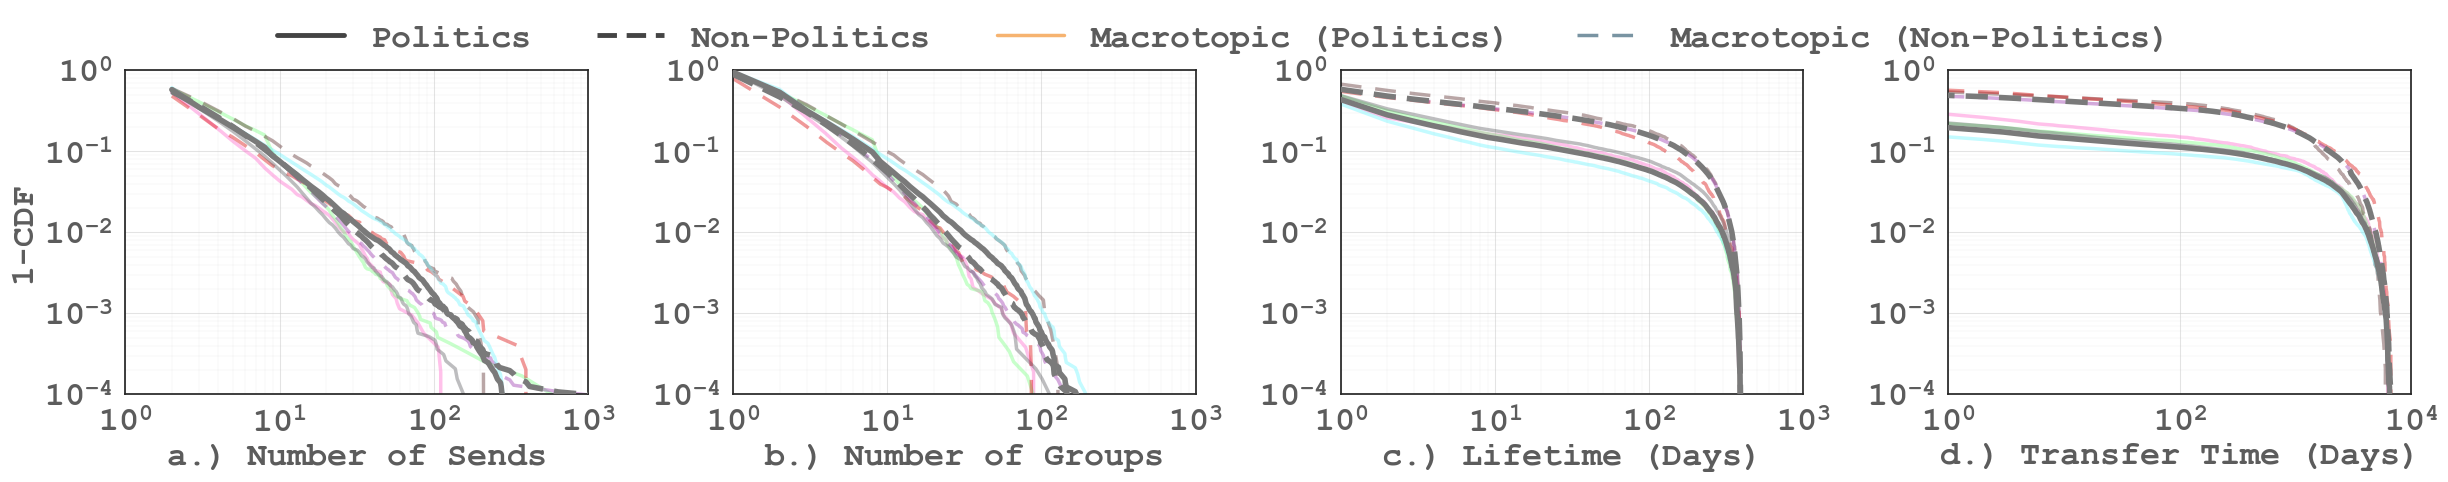

In [75]:
from matplotlib.lines import Line2D

fig, axs = plt.subplots(figsize=(25, 5), ncols=4)

to_plot = ['send_count','groups','lifetime','transfer_time']

for ax, value in zip(axs, to_plot):

    # Macrotópicos (coloridos)
    for idx, df_group in df_resumo.groupby('macrotopic_pred'):
        linestyle = (0, (6, 4)) if idx not in politics else 'solid'
        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)
        if n == 0:
            continue
        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
        ax.plot(xs, y, color=macro_colors[idx], linewidth=2.5, linestyle=linestyle, alpha=0.4, zorder=1)

    # Politics (cinza forte)
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
    ax.plot(xs, y, color="#7a7a7a", linestyle='solid', linewidth=4.0, alpha=1.0, zorder=3)

    # Non-politics (cinza forte tracejado)
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
    ax.plot(xs, y, color='#7a7a7a', linestyle=(0, (4, 2)), linewidth=4.0, alpha=1.0, zorder=3)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

axs[0].set_xlim(1,1000)
axs[0].set_ylim(1e-4,1)
axs[0].set_xlabel('a.) Number of Sends')
axs[0].set_ylabel('1-CDF')

axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-4,1)
axs[1].set_xlabel('b.) Number of Groups')

axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-4,1)
axs[2].set_xlabel('c.) Lifetime (Days)')

axs[3].set_xlim(1,10000)
axs[3].set_ylim(1e-4,1)
axs[3].set_xlabel('d.) Transfer Time (Days)')

legend_elements = [
    Line2D([0], [0], color='#444444', lw=3.5, linestyle='solid', label='Politics'),
    Line2D([0], [0], color='#444444', lw=3.5, linestyle=(0, (4, 2)), label='Non-Politics'),
    Line2D([0], [0], color=palette_map['War'], lw=2.5, linestyle='solid', alpha=0.8, label='Macrotopic (Politics)'),
    Line2D([0], [0], color=palette_map['Religion'], lw=2.5, linestyle=(0, (6, 4)), alpha=0.8, label='Macrotopic (Non-Politics)'),
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("gráficos/ecdf_category_topic3.png", bbox_inches='tight')
plt.show()

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Data Preparation ---
if 'categoria_politica' not in df_resumo.columns:
    df_analise = df_resumo[df_resumo['send_count'] > 1].copy()
    df_analise['categoria_politica'] = df_analise['macrotopic_pred'].apply(classificar_topico)
    df_plot = df_analise[df_analise['categoria_politica'].isin(['politics', 'non-politics'])].copy()
else:
    df_plot = df_resumo[df_resumo['send_count'] > 1].copy()
    df_plot = df_plot[df_plot['categoria_politica'].isin(['politics', 'non-politics'])]

# Métricas
df_plot['taxa_espalhamento'] = df_plot['groups'] / df_plot['send_count']
df_plot['velocidade_expansao'] = df_plot['groups'] / df_plot['lifetime']
df_plot['intensidade_disparo'] = df_plot['send_count'] / df_plot['lifetime']

# --- 2. Helper Function ---
# Adicionamos o argumento 'sort_at_x'
def plot_single_with_zoom(ax, x_col, xlim_main, xlim_zoom, labels, xini_zoom=0, zoom_pos="lower right", sort_at_x=None):
    
    # Se não passar sort_at_x, usa o limite do zoom como padrão
    if sort_at_x is None:
        sort_at_x = xlim_zoom

    # --- MAIN PLOT ---
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='categoria_politica',
        palette=palette_cat, linewidth=3, ax=ax
    )
    
    ax.set_xlim(0, xlim_main)
    ax.set_title(labels['title'], fontsize=12)
    ax.set_xlabel(labels['xlabel'], fontsize=12)
    ax.set_ylabel(labels['ylabel'], fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    legend_loc = "lower right" if zoom_pos == "upper left" else "upper left"
    sns.move_legend(ax, legend_loc, title='Category', frameon=True)

    # --- INSET CONFIGURATION ---
    if zoom_pos == "upper left":
        inset_bounds = [0.1, 0.50, 0.65, 0.40] 
    else: 
        inset_bounds = [0.3, 0.15, 0.6, 0.45] 

    ax_inset = ax.inset_axes(inset_bounds)
    
    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Calcula a altura da linha exatamente no ponto 'sort_at_x' escolhido
    ordem_series = df_plot.groupby('macrotopic_pred')[x_col].apply(
        lambda x: (x <= sort_at_x).mean()
    )
    hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()
    # ----------------------------------------

    # --- INSET PLOT ---
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='macrotopic_pred',
        palette=macro_colors, 
        hue_order=hue_order_list,  # <--- Aplica a ordem calculada
        linewidth=2, ax=ax_inset, legend=True
    )
    
    ax_inset.set_xlim(xini_zoom, xlim_zoom)
    
    # Cosmetics
    ax_inset.set_title(f"Zoom: Topics ({xini_zoom}-{xlim_zoom})", fontsize=9)
    ax_inset.set_xlabel('')
    ax_inset.set_ylabel('')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, linestyle=':', alpha=0.7)
    ax_inset.set_facecolor('white')

    inset_legend_loc = "upper left" if zoom_pos == "upper left" else "lower right"
    bbox = (0, 1) if zoom_pos == "upper left" else (1, 0)
    
    sns.move_legend(
        ax_inset, inset_legend_loc, bbox_to_anchor=bbox,      
        frameon=True, title=None, fontsize='small',    
        labelspacing=0.2, handlelength=1.0        
    )

# --- 3. Generate Grid ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# ==============================================================================
# COL 1: EFFICIENCY -> ZOOM UPPER LEFT (Ordenado em 0.7)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[0],
    x_col='taxa_espalhamento',
    xlim_main=1.1,      
    xini_zoom = 0.4,
    xlim_zoom=1,      
    zoom_pos="upper left",
    sort_at_x=0.7,   # <--- AQUI: Ordena baseado no valor em 0.7
    labels={
        'title': 'Spread Efficiency by Category (+ Topic Zoom)',
        'xlabel': 'Rate (Groups / Sends)',
        'ylabel': 'Cumulative Proportion'
    }
)

# ==============================================================================
# COL 2: EXPLOSIVENESS -> ZOOM LOWER RIGHT (Ordenado em 1.0)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[1],
    x_col='velocidade_expansao',
    xlim_main=10,       
    xlim_zoom=5,
    sort_at_x=1.0,   # <--- AQUI: Ordena baseado no valor em 1.0
    zoom_pos="lower right",
    labels={
        'title': 'Expansion Speed by Category (+ Topic Zoom)',
        'xlabel': 'New Groups / Day',
        'ylabel': ''
    }
)

# ==============================================================================
# COL 3: PRESSURE -> ZOOM LOWER RIGHT (Ordenado em 1.0)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[2],
    x_col='intensidade_disparo',
    xlim_main=10,       
    xlim_zoom=5,
    sort_at_x=1.0,   # <--- AQUI: Ordena baseado no valor em 1.0
    zoom_pos="lower right",
    labels={
        'title': 'Firing Pressure by Category (+ Topic Zoom)',
        'xlabel': 'Sends / Day',
        'ylabel': ''
    }
)

plt.tight_layout()
plt.show()

NameError: name 'classificar_topico' is not defined

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def fit_line_with_ci(ax, x, y, ci=95, n_boot=1000, x_grid=None, **line_kwargs):
    # pulizia
    m = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[m]
    y = np.asarray(y)[m]

    # griglia x
    if x_grid is None:
        x_grid = np.linspace(x.min(), x.max(), 200)

    # fit "centrale" (OLS)
    b1, b0 = np.polyfit(x, y, 1)          # y = b1*x + b0
    y_hat = b1 * x_grid + b0

    # bootstrap della retta
    rng = np.random.default_rng(0)
    preds = np.empty((n_boot, len(x_grid)))

    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)       # resample con replacement
        xb = x[idx]
        yb = y[idx]
        bb1, bb0 = np.polyfit(xb, yb, 1)
        preds[i] = bb1 * x_grid + bb0

    lo = np.percentile(preds, (100 - ci) / 2, axis=0)
    hi = np.percentile(preds, 100 - (100 - ci) / 2, axis=0)

    # plot shadow + linea
    ax.fill_between(x_grid, lo, hi, alpha=0.2)
    ax.plot(x_grid, y_hat, **line_kwargs)

    return b1, b0


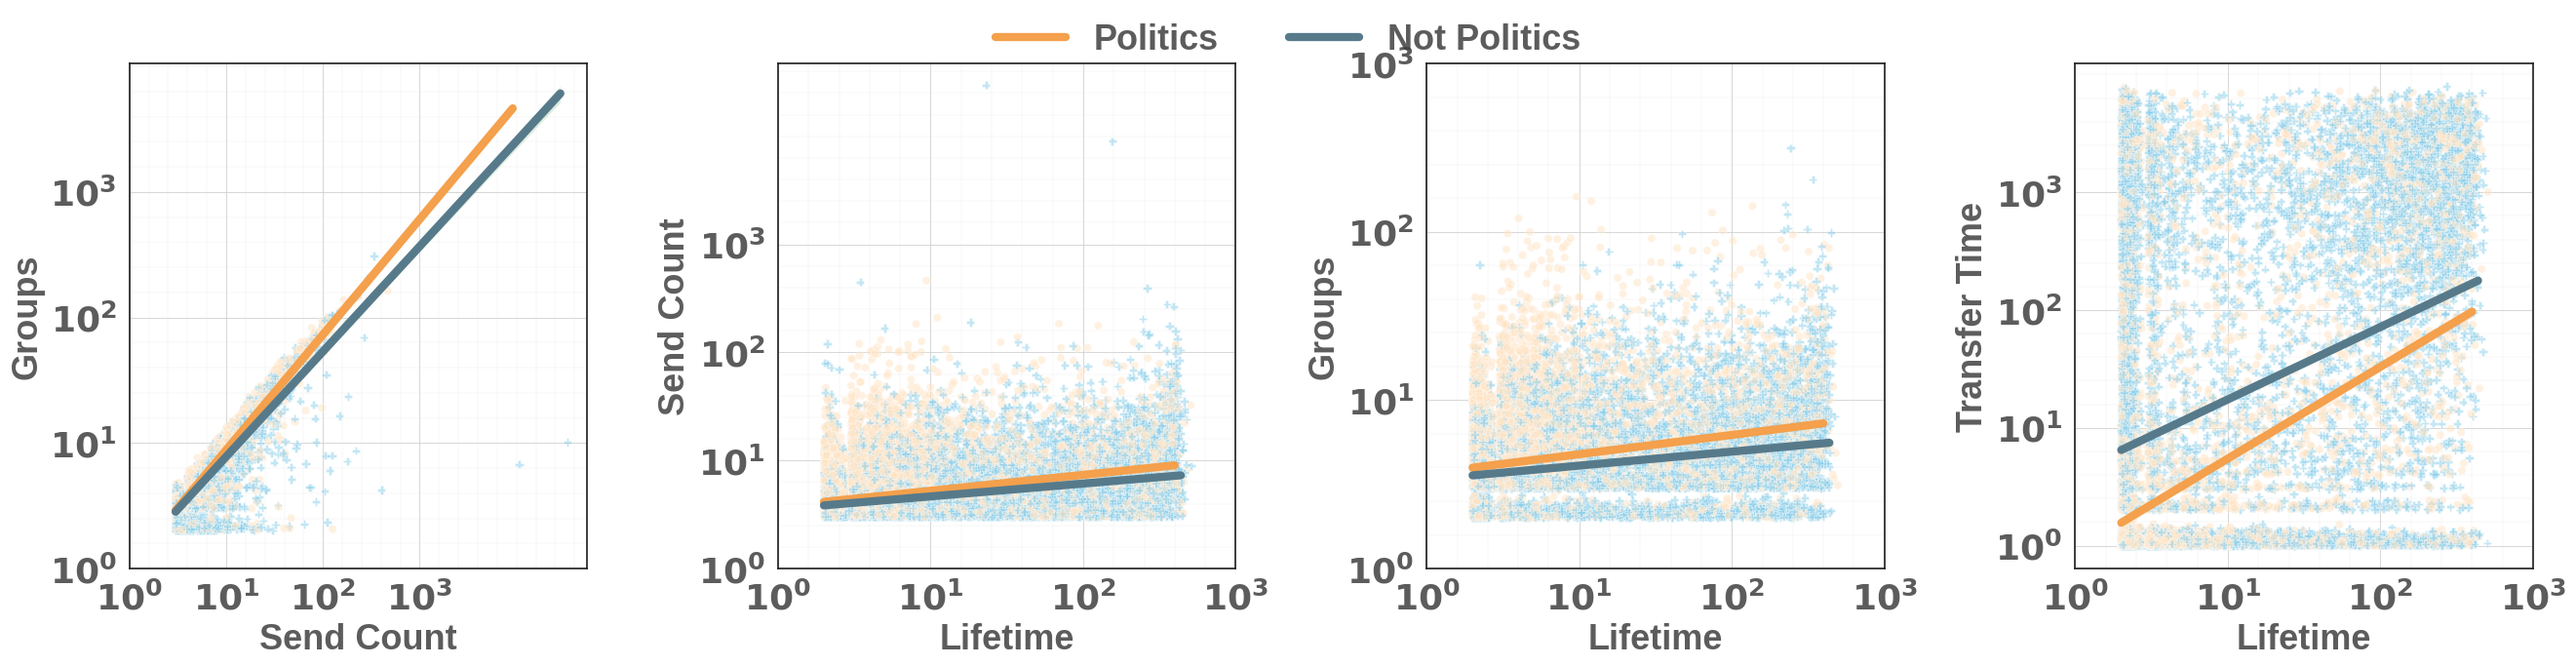

In [80]:
pairs = [
    ('send_count', 'groups'),
    ('lifetime', 'send_count'),
    ('lifetime', 'groups'),
    ('lifetime', 'transfer_time')
]

sigma = 0.05

fig, axes = plt.subplots(1, 4, figsize=(27, 7), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):

    df_resumo_logged = np.log10(df_resumo[[xcol, ycol]]+1).iloc[::5]
    df_politics_logged = np.log10(df_politics[[xcol, ycol]]+1)
    df_non_politics_logged = np.log10(df_non_politics[[xcol, ycol]]+1)

    # mesmo jitter que você usa
    df_resumo_logged += np.abs(
        np.random.normal(0, sigma, size=df_resumo_logged.shape)
    )

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.45)

    sns.scatterplot(
        data=df_resumo_logged,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::5],
        style=df_resumo['Politics'].iloc[::5],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.5,
        sizes=1,
        palette=['skyblue','bisque'],
        markers={True:'o', False:'P'},
        legend=False
    )

    fit_line_with_ci(
        ax,
        df_politics_logged[xcol].to_numpy(),
        df_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color=palette_map['War'],
        lw=6
    )

    fit_line_with_ci(
        ax,
        df_non_politics_logged[xcol].to_numpy(),
        df_non_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color=palette_map['Religion'],
        lw=6
    )

    # ticks no MESMO formato do seu gráfico
    ax.set_xticks(range(4), [rf'$10^{i}$' for i in range(4)])
    ax.set_yticks(range(4), [rf'$10^{i}$' for i in range(4)])

    ax.set_xlabel(xcol.replace('_', ' ').title())
    ax.set_ylabel(ycol.replace('_', ' ').title())

# legenda única
legend_elements = [
    Line2D([0], [0], color=palette_map['War'], lw=6, label='Politics'),
    Line2D([0], [0], color=palette_map['Religion'], lw=6, label='Not Politics')
]

fig.legend(
    handles=legend_elements,
    frameon=False,
    loc='upper center',
    ncol=2, 
    bbox_to_anchor=(0.5, 1.03)
)

plt.tight_layout(rect=[0, 0, 1, 1.03])

plt.tight_layout()
plt.show()


/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.val

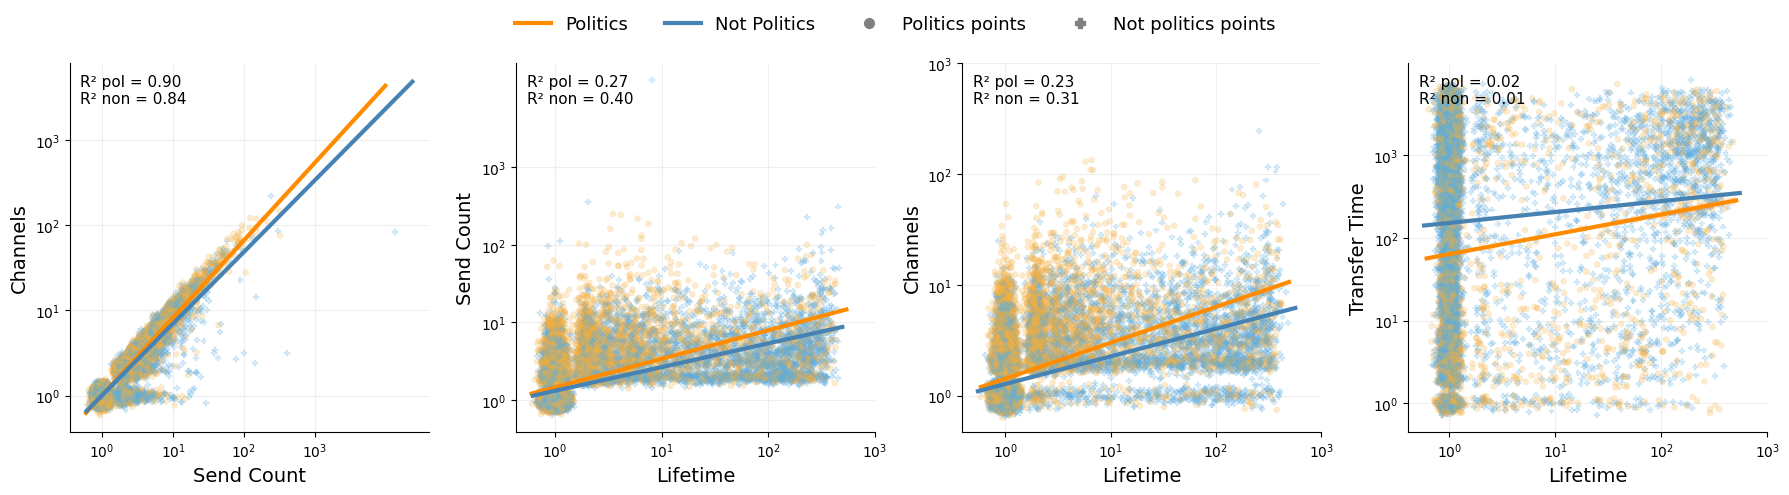

In [ ]:
pairs = [
    ('send_count', 'channels'),
    ('lifetime', 'send_count'),
    ('lifetime', 'channels'),
    ('lifetime', 'transfer_time')
]

sigma = 0.05

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):

    df_all = np.log10(df_resumo[[xcol, ycol]]).iloc[::10].copy()
    pol = np.log10(df_politics[[xcol, ycol]])
    non = np.log10(df_non_politics[[xcol, ycol]])

    # limpa valores inválidos do log
    pol = pol.replace([np.inf, -np.inf], np.nan).dropna()
    non = non.replace([np.inf, -np.inf], np.nan).dropna()

    # jitter consistente (após limpar)
    df_all += np.random.normal(0, sigma, df_all.shape)
    pol    += np.random.normal(0, sigma, pol.shape)
    non    += np.random.normal(0, sigma, non.shape)

    sns.scatterplot(
        data=df_all,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::10],
        style=df_resumo['Politics'].iloc[::10],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.25,
        s=18,
        palette=['#5DADE2', '#F5B041'],
        markers={True: 'o', False: 'P'},
        legend=False,
        edgecolor=None,
        zorder=1
    )

    # regressões
    fit_line_with_ci(
        ax,
        pol[xcol].to_numpy(),
        pol[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='darkorange',
        lw=3,
        zorder=3
    )

    fit_line_with_ci(
        ax,
        non[xcol].to_numpy(),
        non[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='steelblue',
        lw=3,
        zorder=3
    )

    # R² simples
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score

    r2_pol = r2_score(
        pol[ycol],
        LinearRegression().fit(pol[[xcol]], pol[ycol]).predict(pol[[xcol]])
    )

    r2_non = r2_score(
        non[ycol],
        LinearRegression().fit(non[[xcol]], non[ycol]).predict(non[[xcol]])
    )

    ax.text(
        0.03, 0.97,
        f'R² pol = {r2_pol:.2f}\nR² non = {r2_non:.2f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=11
    )

    # ticks no mesmo formato
    ax.set_xticks(range(4), [rf'$10^{i}$' for i in range(4)])
    ax.set_yticks(range(4), [rf'$10^{i}$' for i in range(4)])

    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=14)

    ax.grid(True, which='major', alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


legend_elements = [
    Line2D([0], [0], color='darkorange', lw=3, label='Politics'),
    Line2D([0], [0], color='steelblue', lw=3, label='Not Politics'),
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=7, label='Politics points'),
    Line2D([0], [0], marker='P', color='gray', linestyle='None',
           markersize=7, label='Not politics points')
]

fig.legend(
    handles=legend_elements,
    fontsize=13,
    frameon=False,
    loc='upper center',
    ncol=4
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

___
## **RQ3 Analise temporal de envio do Telegram**

In [26]:
plt.rcParams.update({
    'font.family': 'Liberation Sans',
    'font.size': 32,
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 30,
    'ytick.labelsize': 30,
    'legend.fontsize': 30,
    'figure.titlesize': 32,
})

In [27]:
politics_markers     = ["s", "^", "D", "P", "H", "X"]
non_politics_markers = ["o", "v", "*", "p", "8", "h"]

macro_styles = {}

for i, macro in enumerate(politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": "solid",
        "marker":    politics_markers[i % len(politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

for i, macro in enumerate(non_politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": (0, (2, 2)),
        "marker":    non_politics_markers[i % len(non_politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

In [30]:
def plot_weekly_unique_toxicity_macros(df, title_label, excluded_topics=None):
    if excluded_topics is None:
        excluded_topics = []

    # Limpeza e conversão básica
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start", "perspective_toxicity"])
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # --- O PULO DO GATO ---
    # Removemos duplicatas para que cada vídeo conte apenas uma vez por semana/tópico
    # Se o mesmo vídeo aparece 10x na mesma semana, o drop_duplicates mantém apenas 1 entrada.
    df_unique_weekly = df.drop_duplicates(subset=["week_start", "macrotopic_pred", "video_id"])

    # Agora a média será sobre vídeos ÚNICOS
    grouped = (
        df_unique_weekly.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )
    # ----------------------

    macro_categories = sorted(grouped["macrotopic_pred"].unique())
    
    # Ordenação para a legenda (baseada na última semana)
    last_values = {m: grouped[grouped["macrotopic_pred"] == m].sort_values("week_start")["perspective_toxicity"].iloc[-1] 
                   if not grouped[grouped["macrotopic_pred"] == m].empty else 0 
                   for m in macro_categories}
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    plt.figure(figsize=(18, 8))
    ax = plt.gca()
    # ... (configurações de grid e estilo que você já tem) ...
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style.get("linewidth", 2),
            marker=style["marker"],
            markersize=style.get("markersize", 6),
            label=macro
        )

    # Configuração de Eixos
    week_list = sorted(grouped["week_start"].unique())
    plt.xticks(ticks=week_list[::2], labels=[w.strftime("%d-%m") for w in week_list[::2]], rotation=90)
    plt.xlim(week_list[0], week_list[-1])
    plt.ylabel("Mean Toxicity (Unique Videos)")
    plt.ylim(0, 0.18)

    # Reativando a legenda com a ordem correta
    handles = [Line2D([0], [0], color=macro_styles[m]["color"], linestyle=macro_styles[m]["linestyle"],
                      marker=macro_styles[m]["marker"], markersize=10, label=m) 
               for m in macro_categories_sorted if m in macro_styles]
    plt.legend(handles=handles, loc="upper left", frameon=True, facecolor="white", framealpha=0.8)

    plt.tight_layout()
    plt.show()

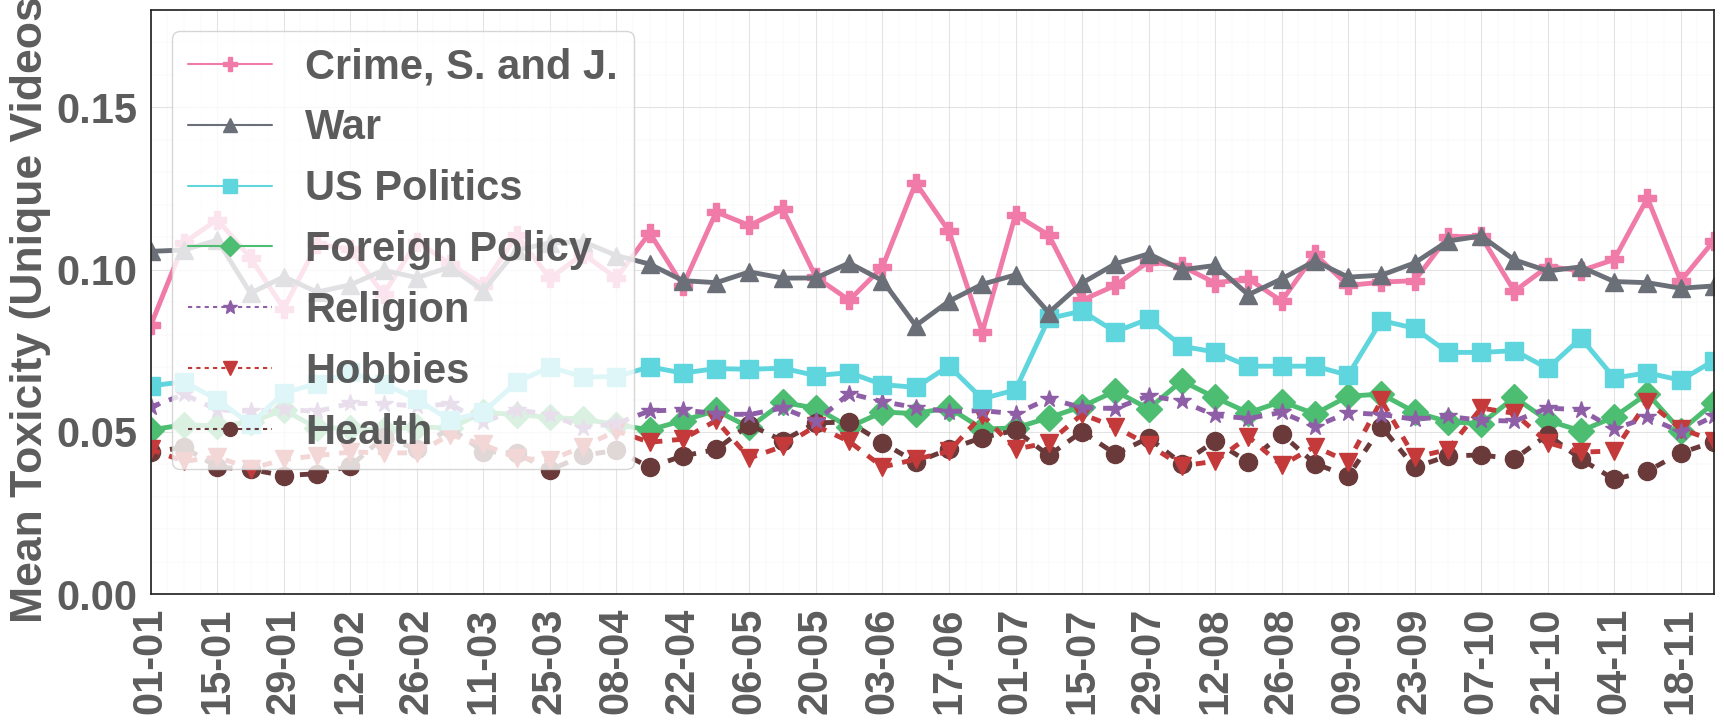

In [31]:
plot_weekly_unique_toxicity_macros(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
)

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

def plot_weekly_toxicity_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    # Limpeza e conversão de datas
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # Início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # Remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # Agrupamento pela média de toxicidade
    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # Pegamos o valor da última semana disponível para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        if not m_df.empty:
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = 0
            
    # Reordena a lista baseada nos valores finais (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    
    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    # Plotagem (usa a lista original para garantir que todas as linhas sejam desenhadas)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style.get("linewidth"),
            marker=style["marker"],
            markersize = style.get("markersize"),
            label=macro
        )

    # Configuração das datas no eixo X
    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(fontsize=25)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly Evolution of Toxicity", fontsize=30)
    plt.xlabel("Week Start Date"
        #, fontsize=30
        )
    plt.ylabel("Mean Toxicity"
        #, fontsize=30
        )

    plt.ylim(0, 0.18)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(0.01))

    """
    handles = [
        Line2D([0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=15,linewidth=3, label=m)
        for m in macro_categories_sorted
    ]

    
    legend = plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    # Ajuste fino do espaçamento interno da legenda
    legend._legend_box.sep = 6
    """

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_toxicity_macros.{format}", format=format, dpi=300, bbox_inches='tight')
    plt.show()

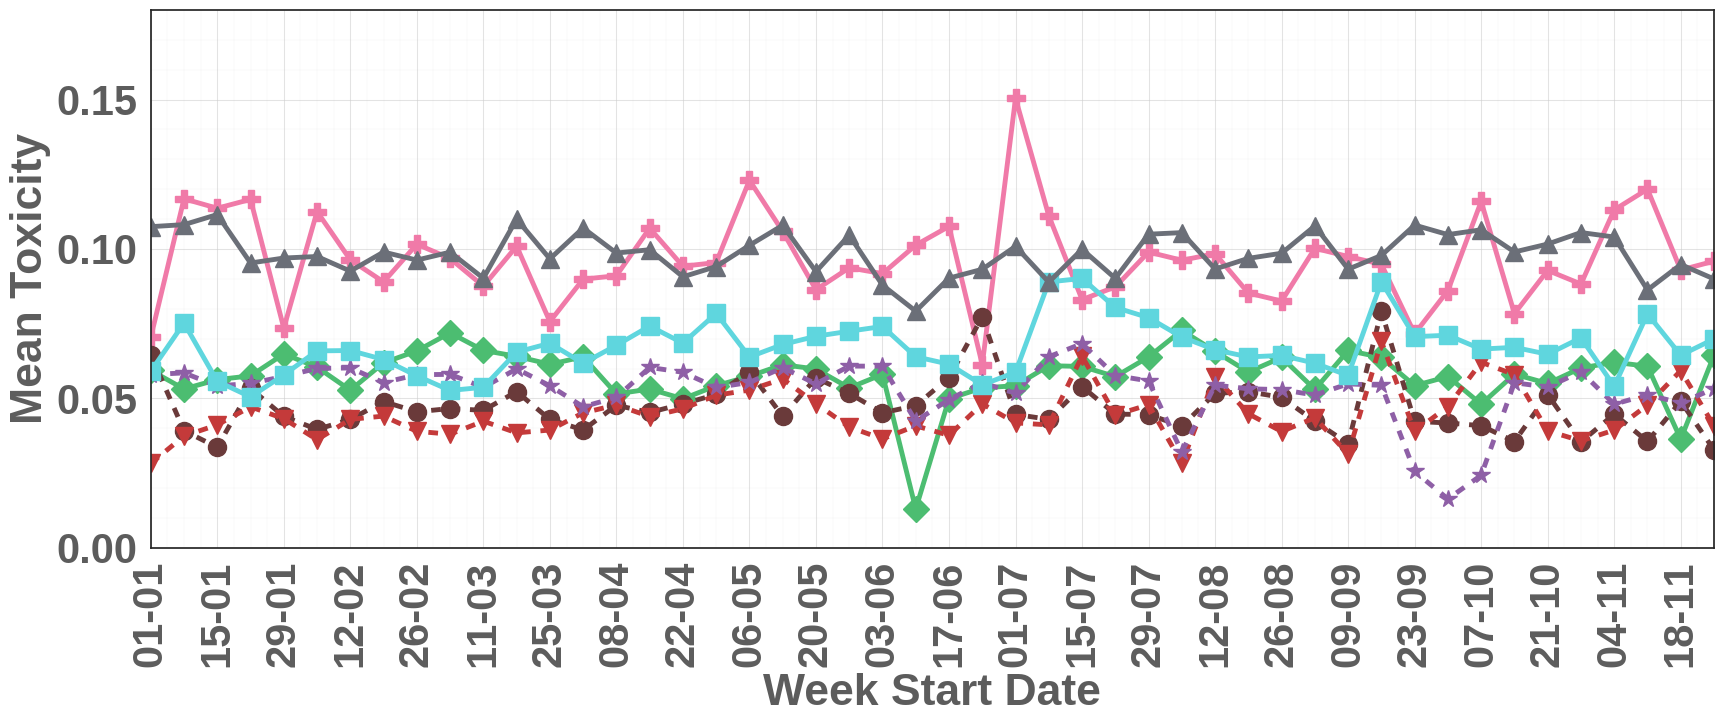

In [96]:
plot_weekly_toxicity_macros(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
)

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch

def plot_weekly_toxicity_macros_v2(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # 🔥 manter apenas uma ocorrência por vídeo
    df = df.drop_duplicates(subset=["video_id"]).copy()

    # início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Vamos pegar o valor da última semana disponível para cada tópico
    # para ordenar a legenda do maior (topo) para o menor (fundo).
    last_week = grouped["week_start"].max()
    
    # Cria um dicionário {topico: valor_ultima_semana}
    # Se um tópico não tiver dados na última semana exata, pegamos o último valor disponível dele.
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Pega o último valor registrado (iloc[-1]) assumindo que o DF está ordenado por data
            # Como agrupamos, garantimos a ordenação:
            m_df = m_df.sort_values("week_start")
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1 # Joga pro final se não tiver dados
            
    # Reordena a lista de categorias baseada nesses valores (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------

    # --- estatísticas globais por macrotópico (ano todo) ---
    stats = (
        df.groupby("macrotopic_pred")["perspective_toxicity"]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean": "global_mean", "std": "global_std"})
    )

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 12))

    # Plotamos usando a lista original ou ordenada (tanto faz pro plot, mas usarei a original para iterar)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        color = macro_colors.get(macro, "#333333")

        # linha temporal (média semanal)
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            marker="o",
            color=color,
            linewidth=2,
            zorder=3
        )

        # ---- média e desvio padrão anual do macrotópico ----
        row = stats[stats["macrotopic_pred"] == macro]

        if not row.empty:
            mu  = row["global_mean"].iloc[0]
            sd  = row["global_std"].iloc[0]

            # linha da média anual
            plt.hlines(
                y=mu,
                xmin=m_df["week_start"].min(),
                xmax=m_df["week_start"].max(),
                colors=color,
                linestyles="dashed",
                linewidth=4,
                alpha=1.0,
                zorder=2
            )


    # 🔥 Datas no padrão inglês
    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(week_list, labels, rotation=90, fontsize=25)
    plt.yticks(fontsize=35)

    plt.title(f"Weekly Evolution of Toxicity — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Mean Toxicity (Unique Videos)", fontsize=30)

    # Cria handles usando a lista ORDENADA (macro_categories_sorted)
    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=20, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    plt.ylim(0.03, 0.13)

    plt.tight_layout()
    plt.show()

In [95]:
plot_weekly_toxicity_macros_v2(df_complete, "All the data")

NameError: name 'plot_weekly_toxicity_macros_v2' is not defined

In [ ]:
def plot_weekly_video_count_macros_v1(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["video_id"]
          .count()
          .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else 0

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 11))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)


    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro,
            {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 10),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )
    
    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(#fontsize=25)
    plt.xlim(week_list[0], week_list[-1])
    

    #plt.title(f"Weekly Number of Videos", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Videos"
               #, fontsize=30
               )

    plt.ylim(0, 15000)
    plt.gca().yaxis.set_major_locator(MultipleLocator(3000))

    handles = [
        Line2D([0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=15,linewidth=3, label=m)
        for m in macro_categories_sorted
    ]

    legend = plt.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=4,
        frameon=False,
        handlelength=1.5,
        handletextpad=0.5,
        columnspacing=1.5
    )

    """
    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )
    """
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_send_count.{format}", format=format, dpi=300, bbox_inches='tight')
    plt.show()

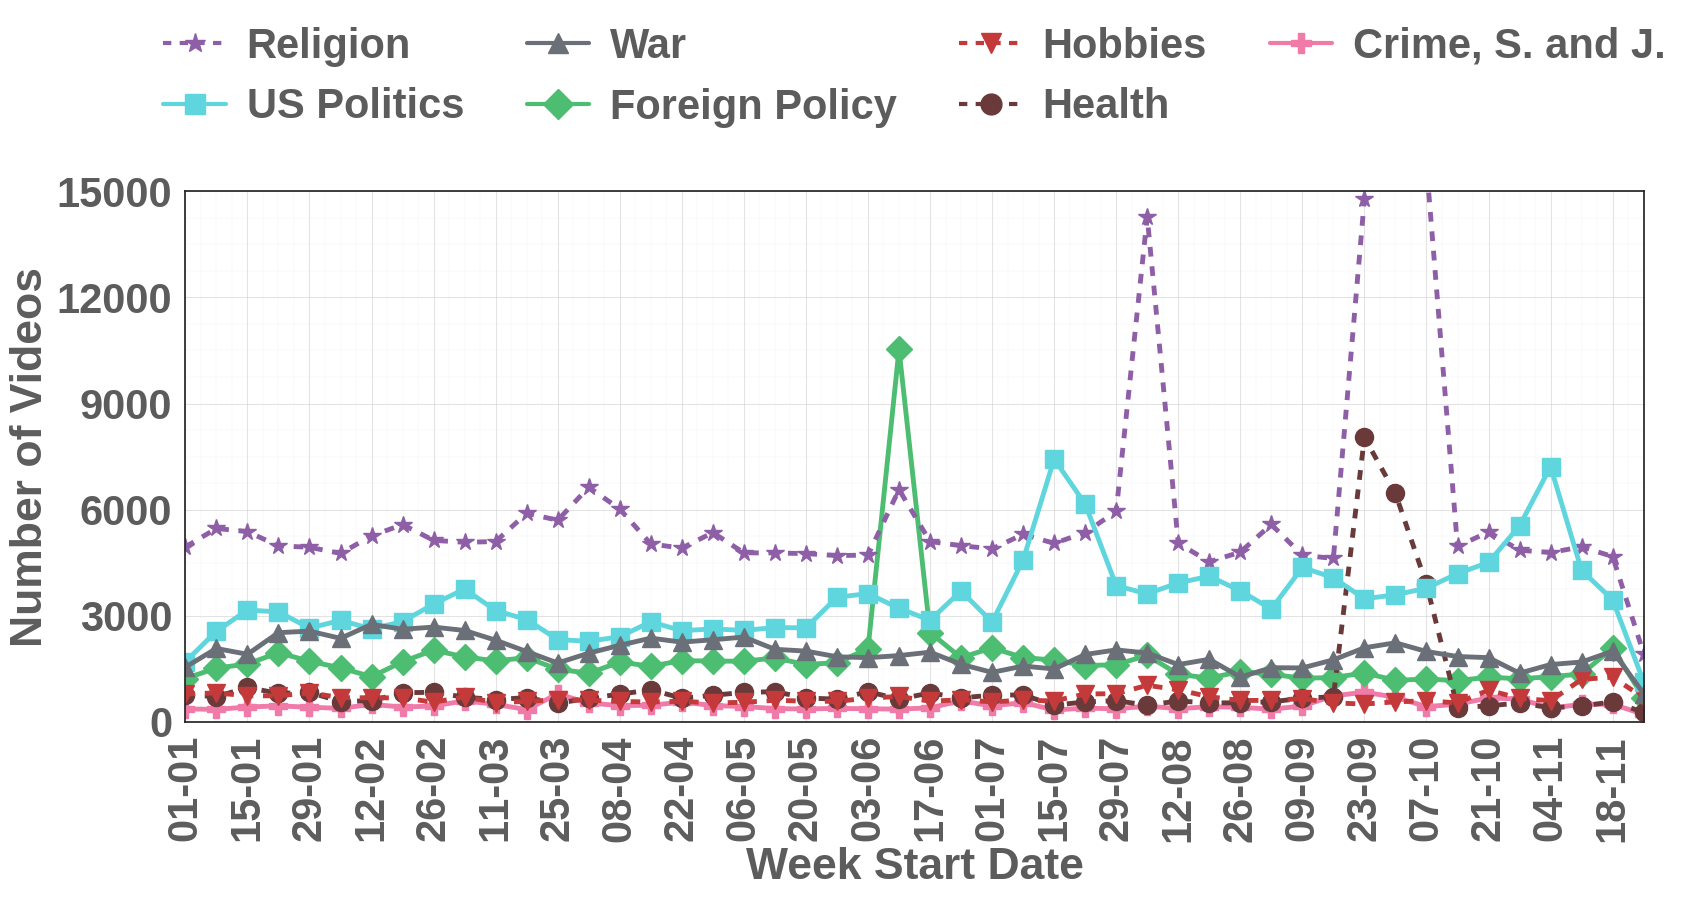

In [129]:
plot_weekly_video_count_macros_v1(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [101]:
def plot_weekly_video_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["video_id", "week_start", "macrotopic_pred"]).copy()

    week_list = sorted(df_unique["week_start"].unique())
    week_map  = {w: i + 1 for i, w in enumerate(week_list)}
    df_unique["week_num"] = df_unique["week_start"].map(week_map)

    grouped = (
        df_unique.groupby(["week_num", "macrotopic_pred"])["video_id"]
        .nunique()
        .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_num")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_num"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_ticks = list(range(1, len(week_list)+1, 2))
    labels = [week_list[i-1].strftime("%d-%m") for i in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
    )
    #plt.yticks(fontsize=25)
    plt.xlim(1, len(week_list))

    #plt.title(f"Weekly Number of Unique Videos", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Unique Videos"
               #, fontsize=30
               )
    lim_y = 4000
    plt.ylim(0, lim_y)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(lim_y/10))
    """
    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=20, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    legend = plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=26,
        #title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    legend._legend_box.sep = 6
    """
    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_unique_video_count.{format}", format=format, bbox_inches='tight')
    plt.show()

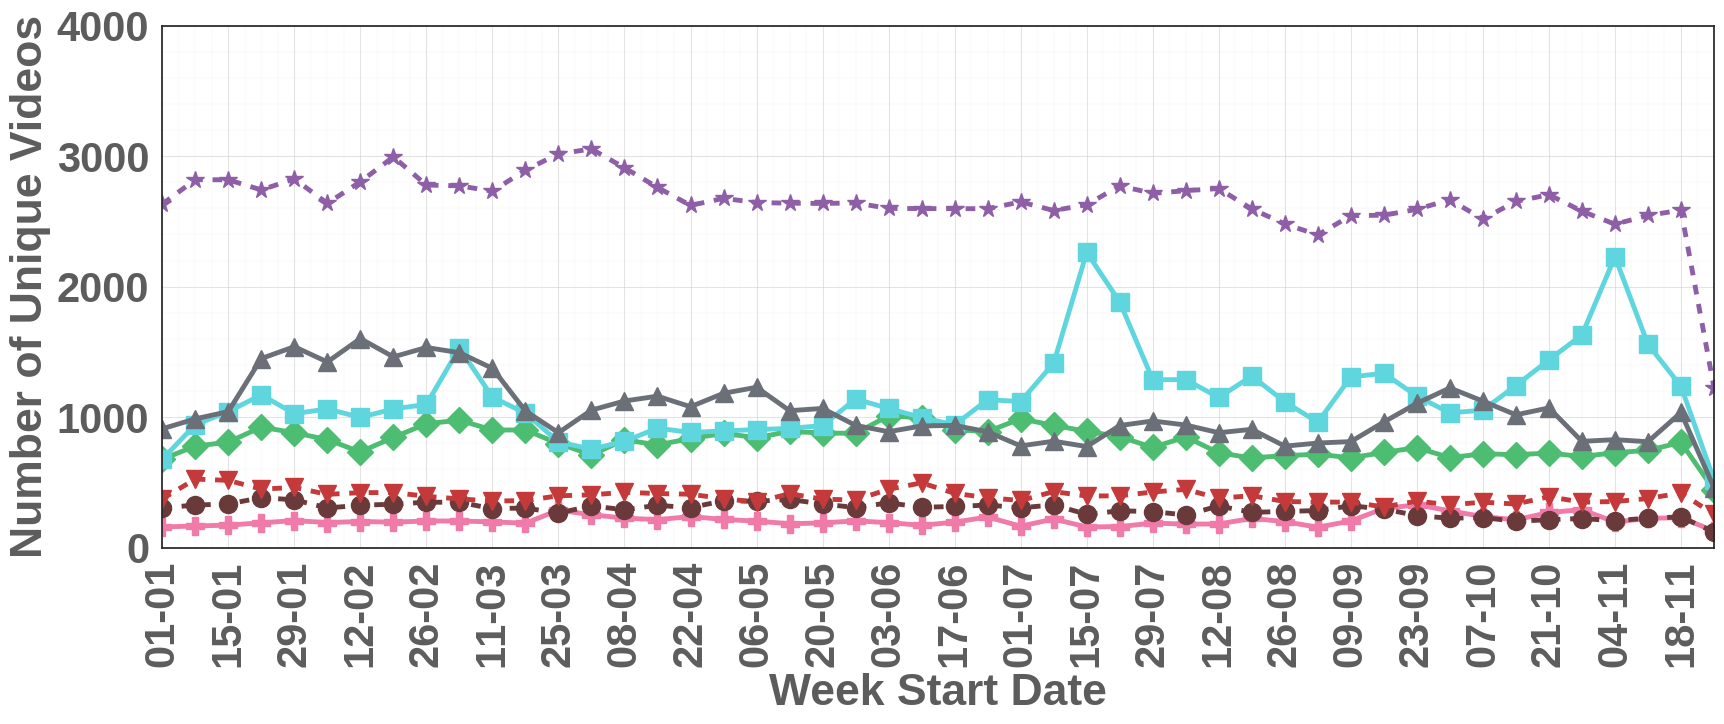

In [102]:
plot_weekly_video_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [120]:
def plot_weekly_channel_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])

    grouped = (
        df_unique
        .groupby(["week_start", "macrotopic_pred"])["folder"]
        .nunique()
        .reset_index(name="channel_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["channel_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    #plt.yticks(fontsize=25)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly Number of Active Channels", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Number of Active Chats"
               #, fontsize=30
               )

    plt.gca().yaxis.set_major_locator(MultipleLocator(200))

    """
    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )
    """
    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_chats_count.{format}", format=format, bbox_inches='tight')
    plt.show()

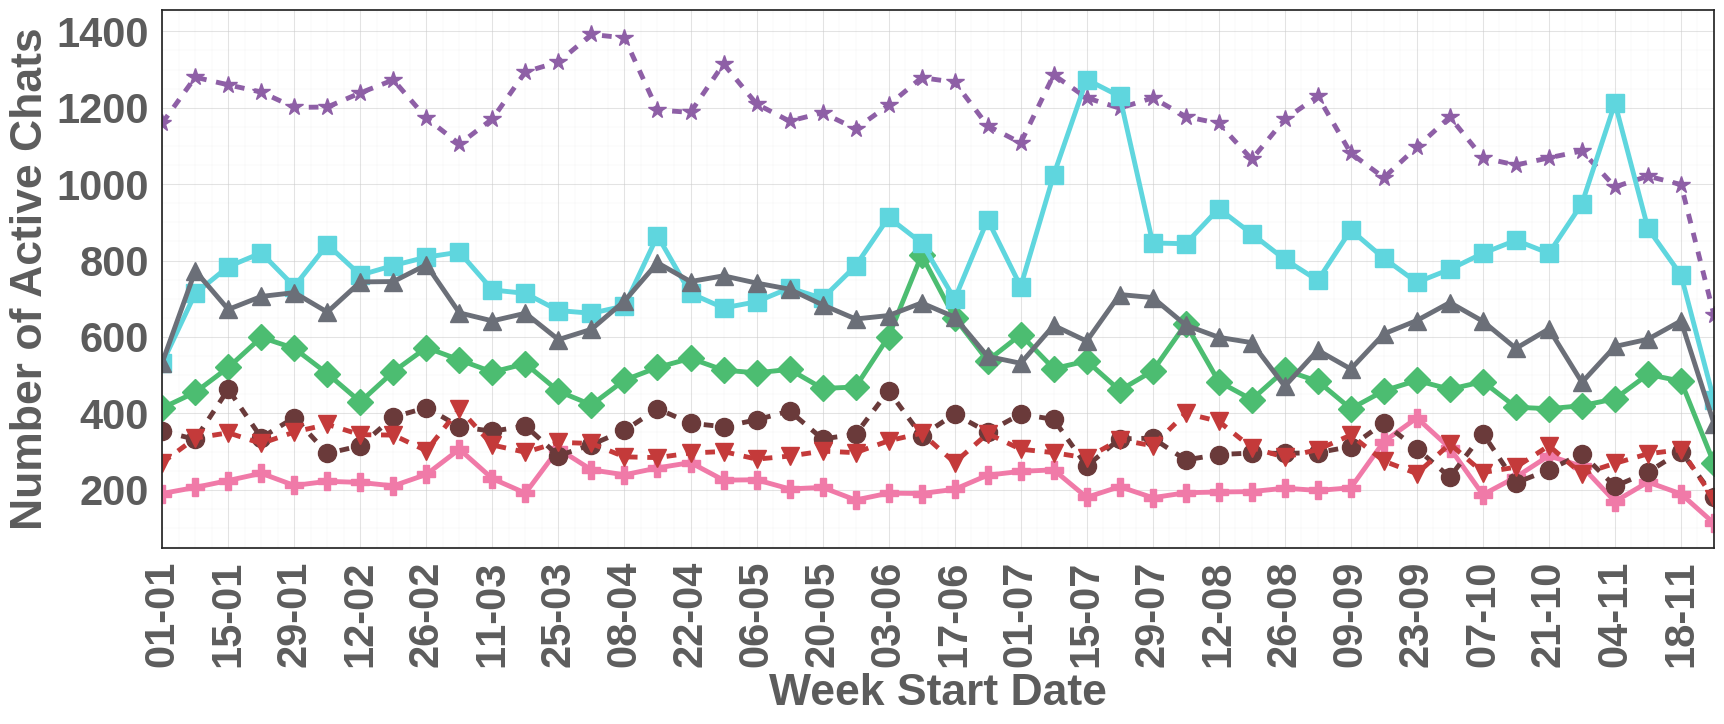

In [121]:
plot_weekly_channel_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_channel_count_macros_2(df, title_label, excluded_topics=None):
    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    # início da semana (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 garantir uma ocorrência por canal por semana por tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    # Ordenar cronologicamente
    df_unique = df_unique.sort_values("week_start")

    # Tabela acumulativa
    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()
        weekly = []

        for week, w_df in m_df.groupby("week_start"):
            new_channels = set(w_df["folder"]) - seen_channels
            seen_channels |= set(w_df["folder"])

            weekly.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "channel_count": len(seen_channels)   # 🔥 acumulado
            })

        grouped.extend(weekly)

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA (NOVO) ---
    # 1. Identifica o valor acumulado final para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Como é cumulativo e ordenado por data, o último registro é o máximo
            m_df = m_df.sort_values("week_start")
            last_val = m_df["channel_count"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1

    # 2. Cria a lista ordenada (Decrescente pelo valor acumulado)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(18, 8))
    #plt.grid(axis="x", visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro, {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style.get("markersize", 12),
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    week_ticks = week_list[::2]
    labels = [w.strftime("%d-%m") for w in week_ticks]

    plt.xticks(
        ticks=week_ticks,
        labels=labels,
        rotation=90
        #fontsize=20  # aumentar tamanho dos ticks
    )
    plt.xlim(week_list[0], week_list[-1])

    #plt.yticks(fontsize=25)

    #plt.title(f"Cumulative Number of Unique Channels", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("Cumulative Unique Chats"
               #, fontsize=30
               )
    plt.gca().yaxis.set_major_locator(MultipleLocator(1000))

    """
    handles = [
        Line2D(
            [0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=macro_styles[m].get("markersize", 12),
            linewidth=macro_styles[m].get("linewidth", 2),
            label=m
        )
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )
    """

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_cumulative_chats_count.{format}", format=format, bbox_inches='tight')
    plt.show()

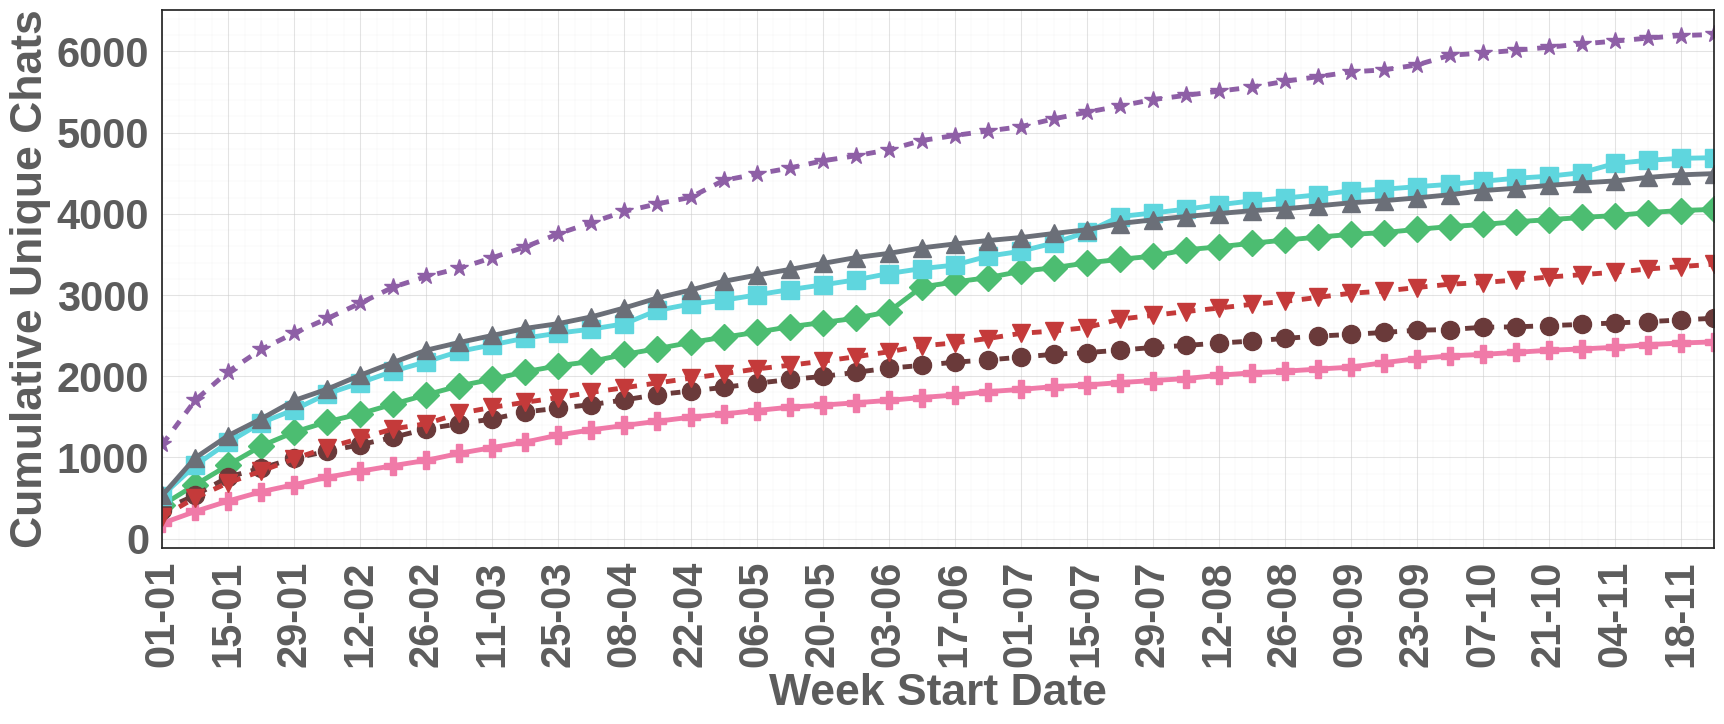

In [125]:
plot_weekly_channel_count_macros_2(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"])

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_new_channel_count_macros(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # uma ocorrência por canal / semana / tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    df_unique = df_unique.sort_values("week_start")

    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()

        for week, w_df in m_df.groupby("week_start"):

            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels

            seen_channels |= current_channels

            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --------- ordenação da legenda (pela soma de novos canais no ano) ---------
    total_new = (
        grouped
        .groupby("macrotopic_pred")["new_channel_count"]
        .sum()
        .to_dict()
    )

    macro_categories_sorted = sorted(
        macro_categories,
        key=lambda x: total_new.get(x, 0),
        reverse=True
    )
    # --------------------------------------------------------------------------

    #sns.set(style="whitegrid")
    plt.figure(figsize=(27, 7))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})

        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(
        ticks=week_list,
        labels=labels,
        rotation=90
        #fontsize=25
    )
    plt.xlim(week_list[0], week_list[-1])
    #plt.yticks(fontsize=30)

    #plt.title(f"Weekly New Unique Channels — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("New Unique Channels"
        #, fontsize=30
        )

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=15, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.show()


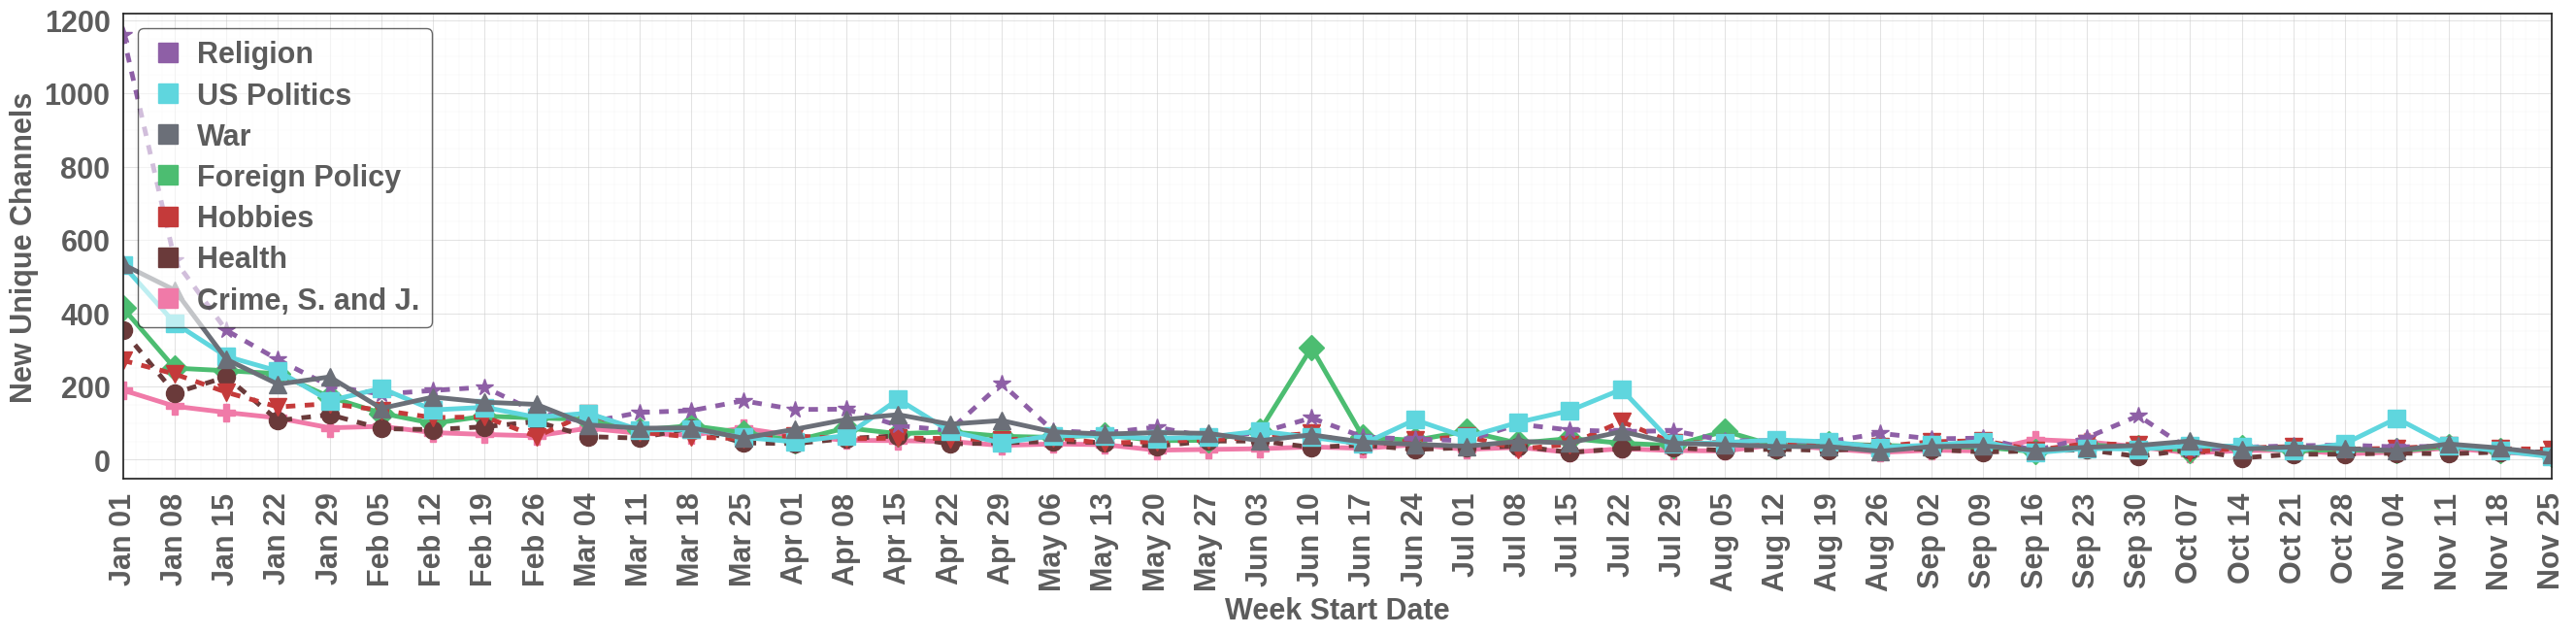

In [40]:
plot_weekly_new_channel_count_macros(df_complete, "All the data")

In [22]:
from matplotlib.ticker import MultipleLocator

def plot_weekly_new_channel_count_macros_zoom(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])
    df_unique = df_unique.sort_values("week_start")

    grouped = []
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        for week, w_df in m_df.groupby("week_start"):
            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels
            seen_channels |= current_channels
            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    total_new = grouped.groupby("macrotopic_pred")["new_channel_count"].sum().to_dict()
    macro_categories_sorted = sorted(macro_categories, key=lambda x: total_new.get(x, 0), reverse=True)

    #sns.set(style="whitegrid")
    plt.figure(figsize=(27, 7))
    #plt.grid(axis='x', visible=False)

    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(ticks=week_list, labels=labels, rotation=90
               #, fontsize=25
               )
    #plt.yticks(fontsize=30)
    plt.xlim(week_list[0], week_list[-1])

    #plt.title(f"Weekly New Unique Channels",fontsize=30)
    plt.xlabel("Week Start Date"
               #, fontsize=30
               )
    plt.ylabel("New Unique Channels"
               #, fontsize=30
               )
    plt.ylim(0, 500)
    #plt.gca().yaxis.set_major_locator(MultipleLocator(50))

    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        #title="Macrotopic",
        #fontsize=24,
        #title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    #sns.despine(top=True, right=True)
    plt.savefig(f"gráficos/weekly_new_channel_count.{format}", format=format, bbox_inches='tight')
    plt.show()

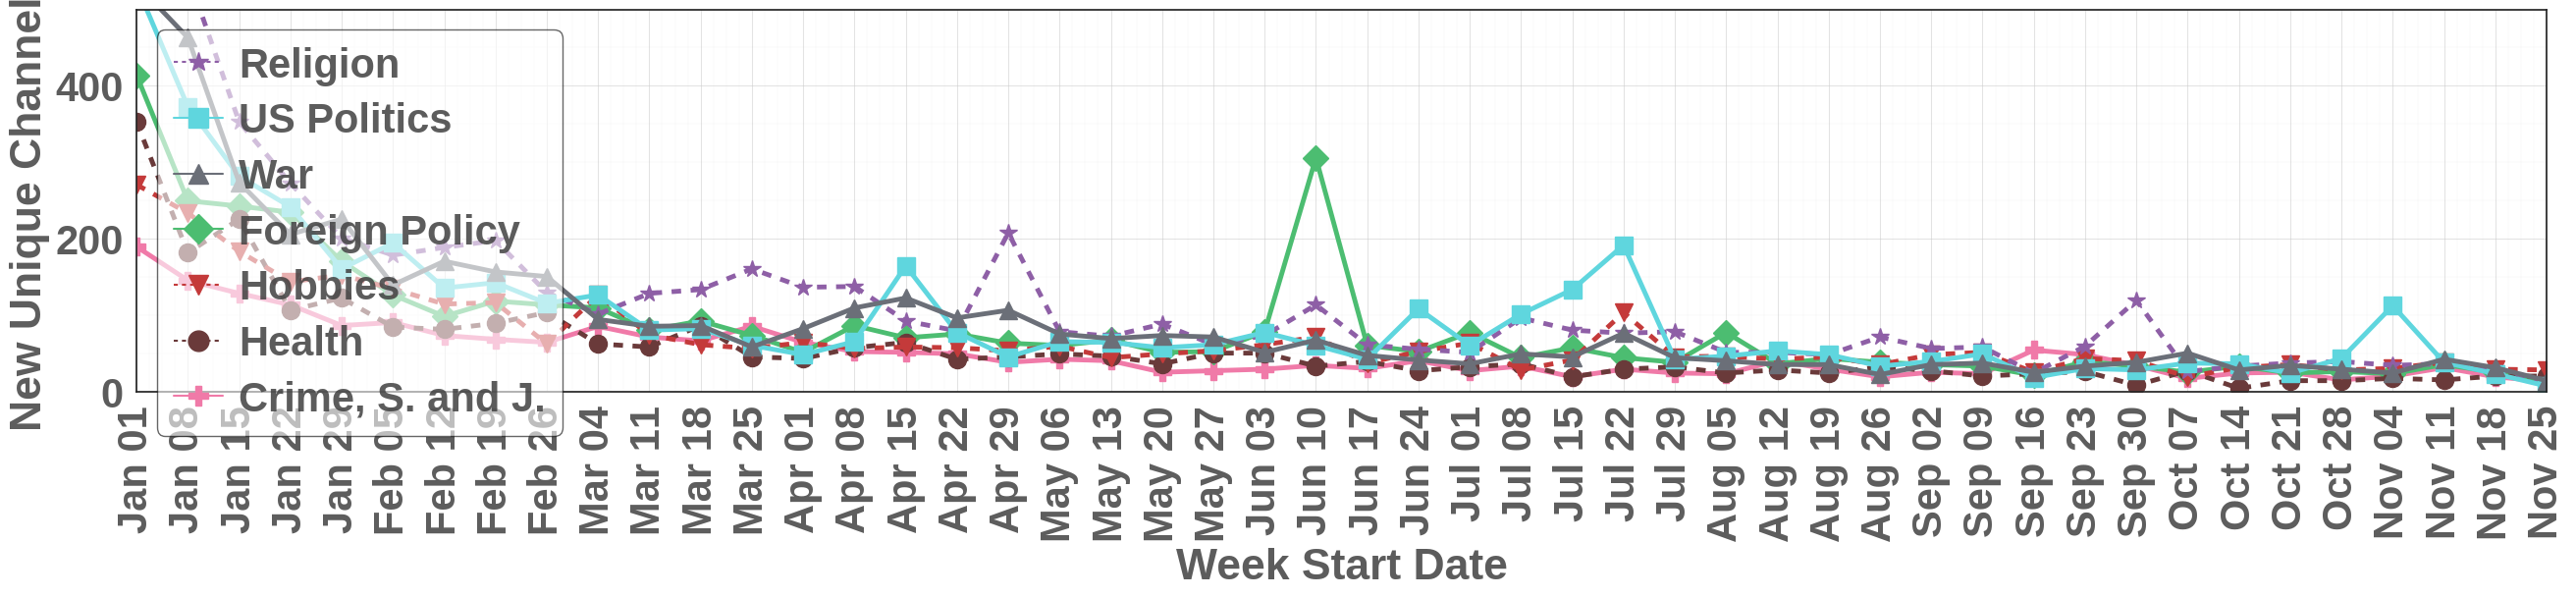

In [26]:
plot_weekly_new_channel_count_macros_zoom(df_complete, "All the data")

In [61]:
def plot_weekly_channels_combined(df, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # ----------------------------
    # ACTIVE CHANNELS
    # ----------------------------
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])

    active = (
        df_unique
        .groupby(["week_start", "macrotopic_pred"])["folder"]
        .nunique()
        .reset_index(name="channel_count")
    )

    # ----------------------------
    # NEW CHANNELS
    # ----------------------------
    df_unique = df_unique.sort_values("week_start")

    new_list = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()

        for week, w_df in m_df.groupby("week_start"):

            current = set(w_df["folder"])
            new_channels = current - seen_channels
            seen_channels |= current

            new_list.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    new_df = pd.DataFrame(new_list)

    macro_categories = sorted(active["macrotopic_pred"].unique())

    plt.figure(figsize=(20,7))
    ax = plt.gca()

    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.55)
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.35)

    for macro in macro_categories:

        active_df = active[active["macrotopic_pred"] == macro]
        new_macro_df = new_df[new_df["macrotopic_pred"] == macro]

        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})

        # Linha principal (canais ativos) — mantém exatamente o seu padrão
        plt.plot(
            active_df["week_start"],
            active_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style.get("markersize", 12),
            linewidth=style.get("linewidth", 2),
            label=macro
        )

        # Linha cinza fina (novos canais)
        plt.plot(
            new_macro_df["week_start"],
            new_macro_df["new_channel_count"],
            color="gray",
            linestyle="solid",
            marker=style["marker"],
            markersize=10,
            linewidth=2,
            alpha=0.7
        )

    week_list = sorted(active["week_start"].unique())
    labels = [w.strftime("%b %d") for w in week_list]

    plt.xticks(week_list, labels, rotation=90)
    plt.xlim(week_list[0], week_list[-1])

    plt.xlabel("Week Start Date")
    plt.ylabel("Number of Channels")

    handles = [
        Line2D([0],[0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15,
               label=m)
        for m in macro_categories if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black"
    )

    plt.tight_layout()
    plt.savefig(f"gráficos/weekly_channel_and_new_count.{format}", format=format, bbox_inches='tight')
    plt.show()

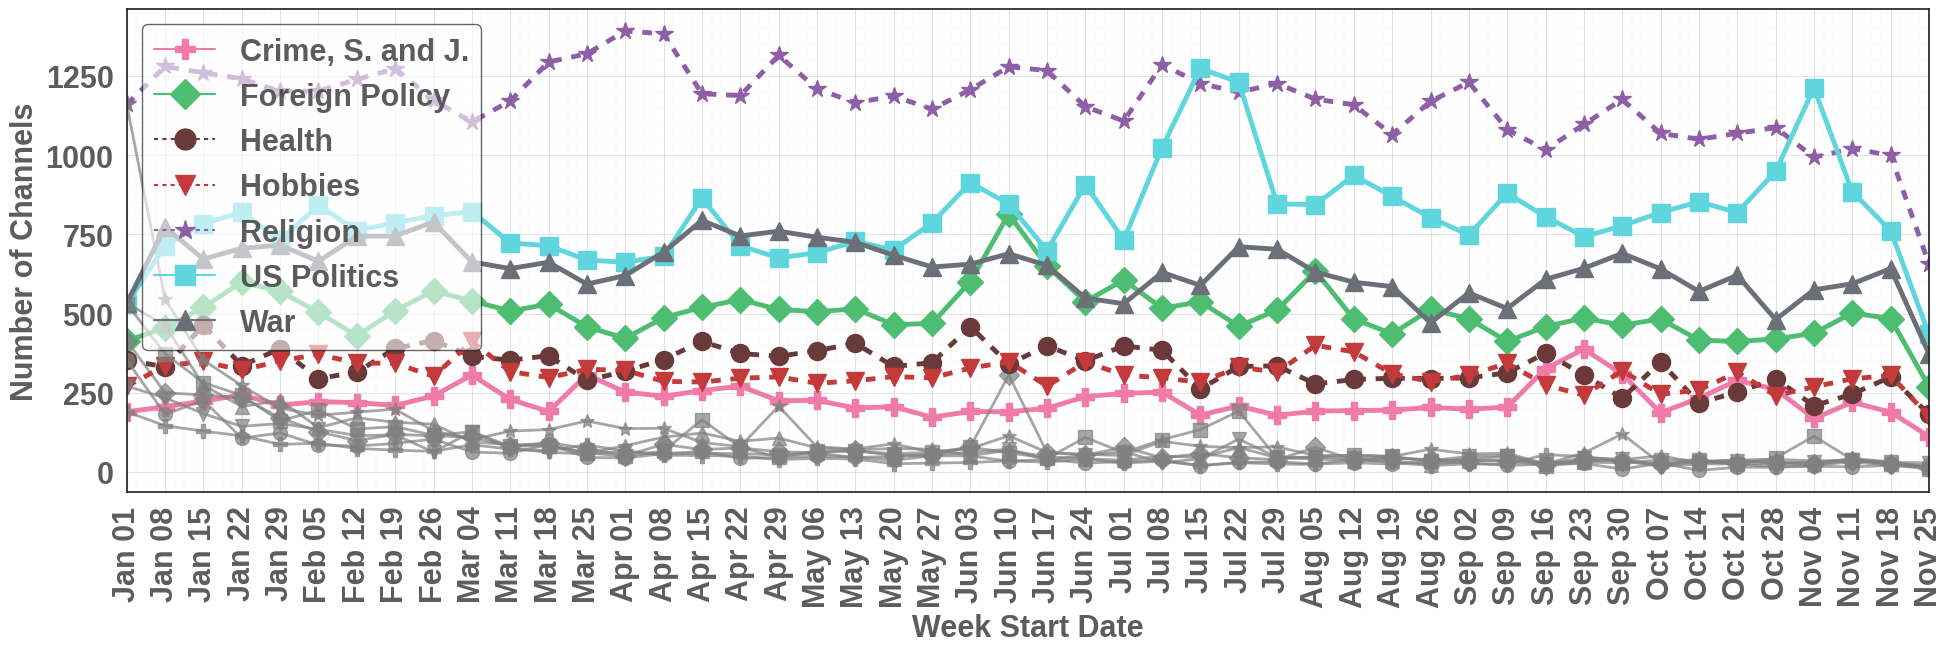

In [62]:
plot_weekly_channels_combined(df_complete)

In [29]:
def calculate_diffusion_metrics(df, threshold=80):
    # 1. Preparação idêntica à sua função de plot
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"]).sort_values("week_start")

    grouped_data = []
    
    # 2. Lógica de "New Channels" (sua lógica original)
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        for week, w_df in m_df.groupby("week_start"):
            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels
            seen_channels |= current_channels

            grouped_data.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped_data)

    # 3. Cálculo da Porcentagem Cumulativa
    # Total de canais únicos por macrotópico ao fim do período
    total_per_macro = grouped.groupby("macrotopic_pred")["new_channel_count"].sum()
    
    # Acumulado semana a semana
    grouped['cumulative_new'] = grouped.groupby("macrotopic_pred")["new_channel_count"].cumsum()
    
    # Porcentagem do total atingida naquela semana
    grouped['pct_reached'] = grouped.apply(
        lambda x: (x['cumulative_new'] / total_per_macro[x['macrotopic_pred']]) * 100, axis=1
    )

    # 4. Encontrar em qual semana cada tópico atingiu o threshold (ex: 80%)
    reach_weeks = []
    for macro in total_per_macro.index:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        # Pega a primeira linha onde a porcentagem >= threshold
        milestone = m_df[m_df['pct_reached'] >= threshold].iloc[0]
        
        # Calcula a distância em semanas desde a primeira semana de dados
        start_date = m_df["week_start"].min()
        weeks_passed = (milestone["week_start"] - start_date).days // 7
        reach_weeks.append(weeks_passed)

    avg_weeks = sum(reach_weeks) / len(reach_weeks)
    
    return avg_weeks, threshold, grouped

# Execução
xx_weeks, yy_percent, df_res = calculate_diffusion_metrics(df_complete, threshold=80)

print(f"Número XX (Semanas): {xx_weeks:.1f}")
print(f"Número YY (Porcentagem): {yy_percent}%")

Número XX (Semanas): 26.7
Número YY (Porcentagem): 80%


In [31]:
import pandas as pd

def get_growth_milestones(df):
    # --- Pré-processamento igual ao seu gráfico ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"]).sort_values("week_start")

    # --- Cálculo do Acumulado ---
    milestones_results = []
    
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        weekly_growth = []
        
        # Coleta o estado de canais vistos por semana
        weeks = sorted(m_df["week_start"].unique())
        start_date = weeks[0]
        
        for week in weeks:
            w_df = m_df[m_df["week_start"] == week]
            seen_channels |= set(w_df["folder"])
            weekly_growth.append({
                "week_num": ((week - start_date).days // 7) + 1,
                "count": len(seen_channels)
            })
        
        # Calcula porcentagens baseadas no valor final do tópico
        final_total = len(seen_channels)
        df_macro = pd.DataFrame(weekly_growth)
        
        # Para cada 10%, encontra a primeira semana que atingiu/passou
        for p in range(10, 101, 10):
            target = (p / 100) * final_total
            # Pega a primeira semana onde o acumulado >= target
            reach_row = df_macro[df_macro["count"] >= target].iloc[0]
            milestones_results.append({
                "macro": macro,
                "percentage": p,
                "weeks": reach_row["week_num"]
            })

    # --- Agregação Final (Média de todos os tópicos) ---
    results_df = pd.DataFrame(milestones_results)
    summary = results_df.groupby("percentage")["weeks"].mean().to_dict()
    
    print("=== Marcos de Crescimento (Média dos Macrotópicos) ===")
    for p, w in summary.items():
        print(f"{p}% - {w:.1f} semanas")
    
    return summary

# Uso:
milestones = get_growth_milestones(df_complete)

=== Marcos de Crescimento (Média dos Macrotópicos) ===
10% - 1.3 semanas
20% - 2.9 semanas
30% - 4.6 semanas
40% - 7.3 semanas
50% - 11.0 semanas
60% - 15.9 semanas
70% - 21.4 semanas
80% - 27.7 semanas
90% - 36.1 semanas
100% - 48.0 semanas


In [33]:
import pandas as pd

def get_total_growth_milestones(df):
    # --- Pré-processamento e Filtro Temporal ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df[(df["date"] >= "2024-01-01") & (df["date"] < "2024-12-01")].copy()
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    
    # Ordenar cronologicamente
    df = df.sort_values("week_start")

    # --- Lógica de Primeira Aparição (Global) ---
    # Identifica a primeira semana de cada canal no dataset inteiro
    first_appearances = df.groupby("folder")["week_start"].min().reset_index()
    
    # Conta quantos novos canais entraram por semana no sistema todo
    weekly_new_users = first_appearances.groupby("week_start").size().reset_index(name="new_channels")
    
    # Cálculo do Acumulado Global
    weekly_new_users["cumulative"] = weekly_new_users["new_channels"].cumsum()
    
    final_total = weekly_new_users["cumulative"].iloc[-1]
    start_date = weekly_new_users["week_start"].min()
    
    print(f"Total de canais únicos no sistema: {final_total}")
    print("=== Marcos de Crescimento (Total Consolidado) ===")
    
    milestones = {}
    for p in range(10, 101, 10):
        target = (p / 100) * final_total
        # Encontra a primeira semana onde o acumulado global atingiu o alvo
        reach_row = weekly_new_users[weekly_new_users["cumulative"] >= target].iloc[0]
        
        weeks_passed = ((reach_row["week_start"] - start_date).days // 7) + 1
        milestones[p] = weeks_passed
        print(f"{p}% - {weeks_passed} semanas ({reach_row['week_start'].strftime('%d-%m-%Y')})")
    
    return milestones

# Execução:
milestones_totais = get_total_growth_milestones(df_complete)

Total de canais únicos no sistema: 9715
=== Marcos de Crescimento (Total Consolidado) ===
10% - 1 semanas (01-01-2024)
20% - 1 semanas (01-01-2024)
30% - 2 semanas (08-01-2024)
40% - 4 semanas (22-01-2024)
50% - 7 semanas (12-02-2024)
60% - 12 semanas (18-03-2024)
70% - 18 semanas (29-04-2024)
80% - 24 semanas (10-06-2024)
90% - 33 semanas (12-08-2024)
100% - 48 semanas (25-11-2024)
